# Pharma Weekly Residual Diagnostics

Notebook ini dibuat untuk membuktikan secara visual mengapa skema **LR + XGBoost residual** hanya membantu sebagian kategori obat. Fokusnya bukan mencari hyperparameter baru, tetapi membaca hasil eksperimen yang sudah selesai, mengambil **best residual method** per kategori, lalu membandingkan residual sebelum dan sesudah koreksi.

Notebook ini tetap Colab-ready seperti notebook enhancement lain:

- Bisa berjalan di lokal atau Google Colab.
- Menggunakan konfigurasi runtime yang sama.
- Menggunakan GEO fallback bila file lokal tidak tersedia.
- Membaca hasil eksperimen dari `OUTPUT_DIR`.
- Menyimpan gambar ke `OUTPUT_DIR / residual_diagnostics_figures`.

Catatan penting: notebook ini **tidak menjalankan optimizer ulang**. Semua parameter model dikunci dari hasil CSV eksperimen sebelumnya agar hasil diagnostic lebih stabil dan mudah direproduksi.

# Runtime Configuration

Set `USE_GOOGLE_COLAB` untuk memilih runtime:

- `False` — lokal / JupyterHub: load `salesweekly.csv` dari `data/raw/pharma-sales`
  di bawah project root.
- `True` — Google Colab: mount Drive dan load dari path Shared Drive.

`QUICK_MODE` mengecilkan jumlah iterasi optimizer untuk uji cepat. Set `False`
untuk run final (iterasi penuh seperti penelitian).

In [1]:
# ============================================================
# Runtime toggle - set sebelum menjalankan cell setup di bawah
# ============================================================
USE_GOOGLE_COLAB = True   # True = Colab + Shared Drive; False = lokal / JupyterHub
QUICK_MODE = False          # True = iterasi kecil (uji cepat); False = iterasi penuh

# Path Shared Drive saat USE_GOOGLE_COLAB=True (folder berisi salesweekly.csv)
COLAB_WEEKLY_DIR = (
    '/content/drive/Shareddrives/Riset S3/Forecasting/'
    'dataset-drug-demand-prediction/pharmasales'
)

print(f'USE_GOOGLE_COLAB = {USE_GOOGLE_COLAB}')
print(f'QUICK_MODE       = {QUICK_MODE}')
if USE_GOOGLE_COLAB:
    print(f'Colab weekly dir : {COLAB_WEEKLY_DIR}')
else:
    print('Dataset akan diresolusi dari project root: data/raw/pharma-sales')

USE_GOOGLE_COLAB = True
QUICK_MODE       = False
Colab weekly dir : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/pharmasales


## Install Dependencies

Di Google Colab, `optuna` dan `pyswarms` belum terpasang secara default. Cell
berikut menginstalnya saat berjalan di Colab (dilewati di lokal / JupyterHub yang
sudah punya dependency).

In [2]:
# Install dependency yang tidak tersedia default di Colab
import importlib, subprocess, sys

_pkgs = {'optuna': 'optuna', 'pyswarms': 'pyswarms', 'xgboost': 'xgboost',
         'statsmodels': 'statsmodels'}
_missing = [pip_name for mod, pip_name in _pkgs.items()
            if importlib.util.find_spec(mod) is None]
if _missing:
    print('Installing:', _missing)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *_missing], check=True)
    print('Selesai install.')
else:
    print('Semua dependency sudah tersedia.')

Installing: ['optuna', 'pyswarms']
Selesai install.


In [3]:
import os
import sys
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
import optuna
from pyswarms.single.global_best import GlobalBestPSO

optuna.logging.set_verbosity(optuna.logging.ERROR)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
sns.set_theme(style="whitegrid")


def resolve_project_root() -> Path:
    """Resolusi repo root saat dijalankan dari notebooks/ atau sejenisnya."""
    root = Path(os.getcwd()).resolve()
    if root.name.lower() in {'explore', 'notebooks', 'notebooks-to-transfers'}:
        root = root.parent
        if root.name.lower() == 'notebooks':
            root = root.parent
    return root


def configure_colab_runtime(use_google_colab: bool, colab_weekly_dir: str):
    """Mount Drive dan kembalikan dir dataset saat Colab; else None."""
    if not use_google_colab:
        return None
    try:
        from google.colab import drive
    except ImportError as exc:
        raise ImportError(
            'USE_GOOGLE_COLAB=True tetapi google.colab tidak tersedia. '
            'Jalankan di Google Colab, atau set USE_GOOGLE_COLAB=False.'
        ) from exc
    drive.mount('/content/drive')
    data_dir = Path(colab_weekly_dir)
    print('[INFO] Google Colab mode aktif.')
    print(f'[INFO] Drive mounted; weekly dir -> {data_dir}')
    return data_dir


if 'USE_GOOGLE_COLAB' not in globals():
    raise NameError('USE_GOOGLE_COLAB belum didefinisikan. Jalankan cell Runtime Configuration dulu.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

COLAB_DATA_DIR = configure_colab_runtime(USE_GOOGLE_COLAB, COLAB_WEEKLY_DIR)

if USE_GOOGLE_COLAB:
    DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR is not None else Path(COLAB_WEEKLY_DIR)
else:
    DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'pharma-sales'

WEEKLY_PATH = DATA_DIR / 'salesweekly.csv'
if not WEEKLY_PATH.exists():
    raise FileNotFoundError(f'salesweekly.csv tidak ditemukan: {WEEKLY_PATH}')

if USE_GOOGLE_COLAB:
    _output_candidates = [
        DATA_DIR / 'weekly_enhancement_outputs',
        Path('/content/drive/MyDrive/pharma_weekly_enhancement_outputs'),
        Path('/content/pharma_weekly_enhancement_outputs'),
    ]
else:
    _output_candidates = [PROJECT_ROOT / 'outputs' / 'enhancements']

OUTPUT_DIR = None
_last_output_error = None
for _candidate in _output_candidates:
    try:
        _candidate.mkdir(parents=True, exist_ok=True)
        _probe = _candidate / '.write_probe'
        _probe.write_text('ok', encoding='utf-8')
        _probe.unlink(missing_ok=True)
        OUTPUT_DIR = _candidate
        break
    except OSError as exc:
        _last_output_error = exc

if OUTPUT_DIR is None:
    raise OSError(f'Tidak ada output directory yang writable. Last error: {_last_output_error}')
if USE_GOOGLE_COLAB and OUTPUT_DIR != _output_candidates[0]:
    print(f'[WARN] Shared Drive output read-only. Fallback output dir -> {OUTPUT_DIR}')

print(f'Runtime mode  : {"Google Colab" if USE_GOOGLE_COLAB else "Lokal / JupyterHub"}')
print(f'Project root  : {PROJECT_ROOT}')
print(f'Data path     : {WEEKLY_PATH}')
print(f'Output dir    : {OUTPUT_DIR}')

# Deteksi GPU XGBoost (opsional, aman jika tidak ada)
try:
    _probe = xgb.XGBRegressor(tree_method='hist', device='cuda', n_estimators=1)
    _probe.fit(np.zeros((4, 2)), np.zeros(4))
    XGB_DEVICE = 'cuda'
except Exception:
    XGB_DEVICE = 'cpu'
print(f'XGBoost device: {XGB_DEVICE}')

Mounted at /content/drive
[INFO] Google Colab mode aktif.
[INFO] Drive mounted; weekly dir -> /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/pharmasales
[WARN] Shared Drive output read-only. Fallback output dir -> /content/drive/MyDrive/pharma_weekly_enhancement_outputs
Runtime mode  : Google Colab
Project root  : /content
Data path     : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/pharmasales/salesweekly.csv
Output dir    : /content/drive/MyDrive/pharma_weekly_enhancement_outputs
XGBoost device: cuda


## Load class GEO (dual-mode)

Lokal: import dari `src/utils/geo.py` (single source of truth di repo).
Colab / standalone: fallback ke definisi inline yang identik dengan file repo,
sehingga notebook tetap jalan tanpa perlu meng-upload file terpisah.

In [4]:
try:
    from src.utils.geo import GEO
    print('[INFO] GEO di-load dari src/utils/geo.py (repo lokal).')
except ImportError:
    # ---- Fallback inline (identik dengan src/utils/geo.py) ----
    class GEO:
        def __init__(self, obj_func, dim, bounds, n_agents=10, max_iter=50):
            self.obj_func = obj_func
            self.dim = dim
            self.bounds = bounds
            self.n_agents = n_agents
            self.max_iter = max_iter

        def optimize(self):
            X = np.random.rand(self.n_agents, self.dim)
            for i in range(self.dim):
                lb, ub = self.bounds[i]
                X[:, i] = lb + (ub - lb) * X[:, i]

            fitness = np.array([self.obj_func(x) for x in X])
            gbest = X[np.argmin(fitness)].copy()
            gbest_fit = np.min(fitness)

            for t in range(self.max_iter):
                alpha = 2 * (1 - t / self.max_iter)
                for i in range(self.n_agents):
                    r1, r2 = np.random.rand(), np.random.rand()
                    A = 2 * alpha * r1 - alpha
                    C = 2 * r2
                    D = abs(C * gbest - X[i])
                    newX = gbest - A * D
                    for d in range(self.dim):
                        lb, ub = self.bounds[d]
                        newX[d] = np.clip(newX[d], lb, ub)
                    new_fit = self.obj_func(newX)
                    if new_fit < fitness[i]:
                        X[i] = newX
                        fitness[i] = new_fit
                if np.min(fitness) < gbest_fit:
                    gbest = X[np.argmin(fitness)].copy()
                    gbest_fit = np.min(fitness)
            return gbest, gbest_fit
    print('[INFO] GEO di-load dari fallback inline (Colab / standalone).')

[INFO] GEO di-load dari fallback inline (Colab / standalone).


In [5]:
# Konfigurasi iterasi optimizer berdasarkan QUICK_MODE
if QUICK_MODE:
    OPT_CFG = {'optuna_trials': 15, 'pso_iters': 10, 'pso_particles': 10,
               'geo_iters': 10, 'geo_agents': 8}
else:
    OPT_CFG = {'optuna_trials': 50, 'pso_iters': 30, 'pso_particles': 20,
               'geo_iters': 30, 'geo_agents': 15}
print('OPT_CFG =', OPT_CFG)

OPT_CFG = {'optuna_trials': 50, 'pso_iters': 30, 'pso_particles': 20, 'geo_iters': 30, 'geo_agents': 15}


# Load Data

In [6]:
data = pd.read_csv(WEEKLY_PATH)
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
data['datum'] = pd.to_datetime(data['datum'])
print('Shape:', data.shape)
data.head()

Shape: (302, 9)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


# Feature Engineering (ACF-based)

Pemilihan lag memakai **ACF** (sesuai konvensi eksperimen daily). Untuk tiap
kategori, hitung ACF sampai `nlags=26`, ambil lag yang **signifikan** (di atas
pita kepercayaan 95% ~ `1.96/sqrt(N)`). Baseline (Section 1) memakai lag ACF +
rolling mean; Section 2 menambah fitur musiman.

In [7]:
ACF_NLAGS = 26

def select_acf_lags(series, nlags=ACF_NLAGS):
    """Kembalikan daftar lag signifikan (>95% CI) + lag maksimum untuk rolling."""
    vals = acf(series.dropna(), nlags=nlags, fft=False)
    n = len(series.dropna())
    conf = 1.96 / np.sqrt(n)
    sig = [lag for lag in range(1, nlags + 1) if abs(vals[lag]) > conf]
    if not sig:                       # fallback: lag dgn |ACF| tertinggi
        sig = [int(np.argmax(np.abs(vals[1:])) + 1)]
    return sig, max(sig)


def build_features(df, category, seasonal=False):
    """Bangun DataFrame fitur untuk satu kategori.

    seasonal=False -> baseline: lag ACF signifikan + 1 rolling mean.
    seasonal=True  -> tambah Fourier(52), kalender, rolling std/min/max, diff.
    """
    dfg = df[['datum', category]].rename(columns={'datum': 'ds', category: 'y'}).copy()
    dfg['ds'] = pd.to_datetime(dfg['ds'])

    sig_lags, max_lag = select_acf_lags(dfg['y'])
    for lag in sig_lags:
        dfg[f'lag_{lag}'] = dfg['y'].shift(lag)
    dfg[f'rolling_mean_{max_lag}'] = dfg['y'].shift(1).rolling(window=max_lag).mean()

    if seasonal:
        # Fourier terms untuk siklus tahunan (~52 minggu)
        woy = dfg['ds'].dt.isocalendar().week.astype(int)
        for k in (1, 2, 3):
            dfg[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * woy / 52.0)
            dfg[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * woy / 52.0)
        dfg['week_of_year'] = woy
        dfg['month'] = dfg['ds'].dt.month
        dfg['quarter'] = dfg['ds'].dt.quarter
        dfg[f'rolling_std_{max_lag}'] = dfg['y'].shift(1).rolling(max_lag).std()
        dfg[f'rolling_min_{max_lag}'] = dfg['y'].shift(1).rolling(max_lag).min()
        dfg[f'rolling_max_{max_lag}'] = dfg['y'].shift(1).rolling(max_lag).max()
        dfg['diff_1'] = dfg['y'].diff().shift(1)

    dfg = dfg.dropna().reset_index(drop=True)
    return dfg


def make_splits(df, seasonal=False):
    """Bangun data per kategori: train/val/test (70/10/20 kronologis)."""
    out = []
    for category in categories:
        dfg = build_features(df, category, seasonal=seasonal)
        n = len(dfg)
        train_size = int(n * 0.7)
        val_size = int(n * 0.1)
        dfgtrain = dfg.iloc[:train_size]
        dfgval = dfg.iloc[train_size:train_size + val_size]
        dfgtest = dfg.iloc[train_size + val_size:]
        feat_cols = [c for c in dfg.columns if c not in ('ds', 'y')]
        out.append({
            'category': category,
            'dfgTest': dfgtest,
            'n_features': len(feat_cols),
            'data': {
                'X_train': dfgtrain[feat_cols].to_numpy(),
                'y_train': dfgtrain['y'].to_numpy(),
                'X_val': dfgval[feat_cols].to_numpy(),
                'y_val': dfgval['y'].to_numpy(),
                'X_test': dfgtest[feat_cols].to_numpy(),
                'y_test': dfgtest['y'].to_numpy(),
            }
        })
    return out

## Mesin eksperimen

`run_experiment(cfg, feature_sets, label)` menjalankan **4 optimizer × 2 skema
hybrid** untuk 8 kategori. Semua optimizer **meminimalkan RMSE validation**;
model terbaik lalu di-fit ulang di train dan dievaluasi di **test** (MSE & RMSE).

`cfg` (dict) mengontrol tiap enhancement:
- `xgb_space`: `'base'` (3 HP) atau `'expanded'` (8 HP).
- `early_stopping`: bool.
- `target_transform`: `None` atau `'log1p'` (model di ruang tertransformasi).
- `xgb_objective`: `'reg:squarederror'` | `'count:poisson'` | `'reg:tweedie'` | `'reg:pseudohubererror'`.
- `winsorize`: `None` atau `(low_pct, high_pct)` clip target train.

Catatan: untuk `count:poisson`/`reg:tweedie` pada skema **residual**, target
residual yang negatif di-clip ke 0 (objective ini butuh target non-negatif) —
ini simplifikasi yang didokumentasikan.

In [8]:
PARAM_ORDER_BASE = ['n_estimators', 'max_depth', 'learning_rate']
PARAM_EXTRA = ['reg_alpha', 'reg_lambda', 'subsample', 'colsample_bytree', 'min_child_weight']

BOUNDS_BASE = {
    'n_estimators': (50, 500), 'max_depth': (3, 10), 'learning_rate': (0.01, 0.3),
}
BOUNDS_EXTRA = {
    'reg_alpha': (0.0, 5.0), 'reg_lambda': (0.0, 5.0), 'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0), 'min_child_weight': (1, 10),
}

GRID_BASE = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
}
GRID_EXTRA = {                         # nilai ringkas agar grid tetap feasible
    'reg_alpha': [0.0, 1.0],
    'reg_lambda': [1.0, 3.0],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 5],
}


def _param_names(cfg):
    return PARAM_ORDER_BASE + (PARAM_EXTRA if cfg['xgb_space'] == 'expanded' else [])


def _bounds_list(cfg):
    names = _param_names(cfg)
    b = {**BOUNDS_BASE, **BOUNDS_EXTRA}
    return [b[n] for n in names]


def _decode_vector(vec, cfg):
    """Vektor kontinu (PSO/GEO) -> dict param XGBoost valid."""
    names = _param_names(cfg)
    p = {}
    for i, name in enumerate(names):
        v = vec[i]
        if name == 'n_estimators':
            p[name] = int(np.clip(round(v / 50) * 50, 50, 500))
        elif name == 'max_depth':
            p[name] = int(np.clip(round(v), 3, 10))
        elif name == 'min_child_weight':
            p[name] = int(np.clip(round(v), 1, 10))
        elif name == 'learning_rate':
            p[name] = float(np.clip(v, 0.01, 0.3))
        elif name in ('subsample', 'colsample_bytree'):
            p[name] = float(np.clip(v, 0.5, 1.0))
        else:                          # reg_alpha, reg_lambda
            p[name] = float(np.clip(v, 0.0, 5.0))
    return p


def _make_xgb(params, cfg):
    kw = dict(objective=cfg.get('xgb_objective', 'reg:squarederror'),
              random_state=SEED, n_jobs=-1, tree_method='hist', device=XGB_DEVICE)
    if cfg.get('xgb_objective') == 'reg:tweedie':
        kw['tweedie_variance_power'] = 1.3
    kw.update(params)
    return xgb.XGBRegressor(**kw)


def _t_fwd(y, cfg):
    return np.log1p(y) if cfg.get('target_transform') == 'log1p' else y


def _t_inv(y, cfg):
    return np.expm1(y) if cfg.get('target_transform') == 'log1p' else y


def _needs_nonneg(cfg):
    return cfg.get('xgb_objective') in ('count:poisson', 'reg:tweedie')


def _fit_predict(params, cfg, scheme, Xtr, ytr, Xval, yval, Xpred):
    """Fit LR+XGB (skema tertentu) di train, prediksi Xpred. Ruang asli (y)."""
    if cfg.get('winsorize') is not None:
        lo, hi = np.percentile(ytr, cfg['winsorize'])
        ytr = np.clip(ytr, lo, hi)

    ytr_t = _t_fwd(ytr, cfg)
    lr = LinearRegression().fit(Xtr, ytr_t)
    lr_pred_pred = lr.predict(Xpred)

    model = _make_xgb(params, cfg)
    fit_kw = {}
    if cfg.get('early_stopping'):
        model.set_params(early_stopping_rounds=20)

    if scheme == 'averaging':
        xgb_target = ytr_t
        if _needs_nonneg(cfg):
            xgb_target = np.clip(xgb_target, 0, None)
        if cfg.get('early_stopping'):
            fit_kw['eval_set'] = [(Xval, _t_fwd(yval, cfg))]
            fit_kw['verbose'] = False
        model.fit(Xtr, xgb_target, **fit_kw)
        pred_t = (lr_pred_pred + model.predict(Xpred)) / 2.0
    else:  # residual
        resid = ytr_t - lr.predict(Xtr)
        if _needs_nonneg(cfg):
            resid = np.clip(resid, 0, None)
        if cfg.get('early_stopping'):
            resid_val = _t_fwd(yval, cfg) - lr.predict(Xval)
            if _needs_nonneg(cfg):
                resid_val = np.clip(resid_val, 0, None)
            fit_kw['eval_set'] = [(Xval, resid_val)]
            fit_kw['verbose'] = False
        model.fit(Xtr, resid, **fit_kw)
        pred_t = lr_pred_pred + model.predict(Xpred)

    return _t_inv(pred_t, cfg)


def _val_rmse(params, cfg, scheme, d):
    try:
        pred = _fit_predict(params, cfg, scheme,
                            d['X_train'], d['y_train'], d['X_val'], d['y_val'], d['X_val'])
        return float(np.sqrt(mean_squared_error(d['y_val'], pred)))
    except Exception:
        return 1e12

In [9]:
def _search_grid(cfg, scheme, d):
    grid = {**GRID_BASE}
    if cfg['xgb_space'] == 'expanded':
        grid = {**grid, **GRID_EXTRA}
    best_p, best_v = None, np.inf
    for params in ParameterGrid(grid):
        v = _val_rmse(params, cfg, scheme, d)
        if v < best_v:
            best_v, best_p = v, params
    return best_p


def _search_optuna(cfg, scheme, d):
    names = _param_names(cfg)

    def objective(trial):
        p = {}
        for n in names:
            lo, hi = {**BOUNDS_BASE, **BOUNDS_EXTRA}[n]
            if n == 'n_estimators':
                p[n] = trial.suggest_int(n, 50, 500, step=50)
            elif n in ('max_depth', 'min_child_weight'):
                p[n] = trial.suggest_int(n, int(lo), int(hi))
            else:
                p[n] = trial.suggest_float(n, lo, hi)
        return _val_rmse(p, cfg, scheme, d)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=OPT_CFG['optuna_trials'], show_progress_bar=False)
    return study.best_params


def _search_pso(cfg, scheme, d):
    bounds = _bounds_list(cfg)
    lb = np.array([b[0] for b in bounds], dtype=float)
    ub = np.array([b[1] for b in bounds], dtype=float)

    def cost(x):
        return np.array([_val_rmse(_decode_vector(row, cfg), cfg, scheme, d) for row in x])

    opt = GlobalBestPSO(n_particles=OPT_CFG['pso_particles'], dimensions=len(bounds),
                        options={'c1': 0.5, 'c2': 0.3, 'w': 0.9}, bounds=(lb, ub))
    _, best_pos = opt.optimize(cost, iters=OPT_CFG['pso_iters'], verbose=False)
    return _decode_vector(best_pos, cfg)


def _search_geo(cfg, scheme, d):
    bounds = _bounds_list(cfg)

    def obj(vec):
        return _val_rmse(_decode_vector(vec, cfg), cfg, scheme, d)

    geo = GEO(obj, dim=len(bounds), bounds=bounds,
              n_agents=OPT_CFG['geo_agents'], max_iter=OPT_CFG['geo_iters'])
    best_pos, _ = geo.optimize()
    return _decode_vector(best_pos, cfg)


SEARCHERS = {
    'GridSearch': _search_grid,
    'Optuna': _search_optuna,
    'PSO': _search_pso,
    'GEO': _search_geo,
}


def run_experiment(cfg, feature_sets, label, optimizers=None, schemes=None, verbose=True,
                   checkpoint_path=None, resume=True):
    """Jalankan semua optimizer x skema x kategori. Kembalikan DataFrame hasil test.

    Checkpoint & resume:
    - Jika checkpoint_path diberikan, hasil tiap langkah (category, scheme, optimizer)
      langsung disimpan ke CSV checkpoint setelah selesai.
    - Jika notebook dijalankan ulang (mis. setelah koneksi Colab putus), langkah yang
      sudah ada di checkpoint dilewati dan proses lanjut dari langkah berikutnya.
    - Verbose menampilkan timestamp [HH:MM:SS], durasi tiap langkah, dan ETA.
    """
    import time
    import os as _os
    from datetime import datetime

    def _now():
        return datetime.now().strftime('%H:%M:%S')

    def _fmt(sec):
        sec = int(sec)
        h, rem = divmod(sec, 3600)
        m, s = divmod(rem, 60)
        if h:
            return f'{h}h{m:02d}m{s:02d}s'
        if m:
            return f'{m}m{s:02d}s'
        return f'{s}s'

    cfg = {'xgb_space': 'base', 'early_stopping': False, 'target_transform': None,
           'xgb_objective': 'reg:squarederror', 'winsorize': None, **cfg}
    optimizers = optimizers or list(SEARCHERS.keys())
    schemes = schemes or ['averaging', 'residual']

    # --- muat checkpoint (jika ada) ---
    done = {}
    if checkpoint_path is not None and resume and _os.path.exists(checkpoint_path):
        try:
            ckpt_df = pd.read_csv(checkpoint_path)
            for _, r in ckpt_df.iterrows():
                done[(r['category'], r['scheme'], r['optimizer'])] = {
                    'experiment': r.get('experiment', label),
                    'category': r['category'], 'optimizer': r['optimizer'],
                    'scheme': r['scheme'], 'test_MSE': float(r['test_MSE']),
                    'test_RMSE': float(r['test_RMSE']), 'params': r.get('params'),
                }
            print(f'[{_now()}] [RESUME] {len(done)} langkah dimuat dari checkpoint: {checkpoint_path}',
                  flush=True)
        except Exception as exc:
            print(f'[{_now()}] [WARN] gagal baca checkpoint ({exc}); mulai dari awal.', flush=True)
            done = {}

    if checkpoint_path is not None:
        _cp = str(checkpoint_path)
        if _cp.startswith('/content/') and not _cp.startswith('/content/drive/'):
            print(f'[{_now()}] [WARN] checkpoint di {checkpoint_path} EPHEMERAL '
                  f'(hilang saat runtime mati). Simpan di Google Drive agar resume tahan putus koneksi.',
                  flush=True)

    def _save_ckpt(rows):
        if checkpoint_path is not None:
            pd.DataFrame(rows).to_csv(checkpoint_path, index=False)

    n_cat = len(feature_sets)
    total_steps = n_cat * len(schemes) * len(optimizers)
    step = 0
    resumed = 0
    t_start = time.time()
    if verbose:
        print(f'[{_now()}] === [{label}] START | {n_cat} kategori x {len(schemes)} skema x '
              f'{len(optimizers)} optimizer = {total_steps} langkah '
              f'(resume: {len(done)} sudah ada) ===', flush=True)

    rows = []
    for ci, cat in enumerate(feature_sets, 1):
        d = cat['data']
        cat_name = cat['category']
        t_cat = time.time()
        if verbose:
            print(f'[{_now()}] [{label}] ({ci}/{n_cat}) kategori {cat_name} '
                  f'| n_features={cat.get("n_features", "?")} '
                  f'| train={len(d["y_train"])} val={len(d["y_val"])} test={len(d["y_test"])}',
                  flush=True)
        for scheme in schemes:
            for opt_name in optimizers:
                step += 1
                key = (cat_name, scheme, opt_name)
                if key in done:
                    row = done[key]
                    row['experiment'] = label
                    rows.append(row)
                    resumed += 1
                    if verbose:
                        print(f'[{_now()}]   ~~ [{label}] {cat_name} | {scheme:>9} | {opt_name:<10} '
                              f'({step}/{total_steps}) SKIP (checkpoint) '
                              f'| test_RMSE={row["test_RMSE"]:.3f}', flush=True)
                    continue
                t0 = time.time()
                if verbose:
                    print(f'[{_now()}]   -> [{label}] {cat_name} | {scheme:>9} | {opt_name:<10} '
                          f'({step}/{total_steps}) start ...', flush=True)
                best_p = SEARCHERS[opt_name](cfg, scheme, d)
                pred_test = _fit_predict(best_p, cfg, scheme,
                                         d['X_train'], d['y_train'],
                                         d['X_val'], d['y_val'], d['X_test'])
                mse = float(mean_squared_error(d['y_test'], pred_test))
                row = {
                    'experiment': label, 'category': cat_name,
                    'optimizer': opt_name, 'scheme': scheme,
                    'test_MSE': mse, 'test_RMSE': float(np.sqrt(mse)),
                    'params': best_p,
                }
                rows.append(row)
                _save_ckpt(rows)  # simpan langsung tiap langkah
                if verbose:
                    elapsed = time.time() - t_start
                    new_done = step - resumed
                    eta = (elapsed / new_done) * (total_steps - step) if new_done else 0
                    print(f'[{_now()}]   <- [{label}] {cat_name} | {scheme:>9} | {opt_name:<10} '
                          f'({step}/{total_steps}) DONE in {_fmt(time.time() - t0)} '
                          f'| test_RMSE={np.sqrt(mse):.3f} test_MSE={mse:.3f} '
                          f'| elapsed {_fmt(elapsed)} | ETA {_fmt(eta)}', flush=True)
        if verbose:
            elapsed = time.time() - t_start
            print(f'[{_now()}] [{label}] kategori {cat_name} SELESAI dalam '
                  f'{_fmt(time.time() - t_cat)} | total berjalan {_fmt(elapsed)}', flush=True)
    if verbose:
        print(f'[{_now()}] === [{label}] SELESAI TOTAL dalam {_fmt(time.time() - t_start)} '
              f'({len(rows)} baris hasil, {resumed} dari checkpoint) ===', flush=True)
    return pd.DataFrame(rows)

def show_result(res_df, baseline_df=None):
    """Tampilkan tabel ringkas + delta test_MSE vs baseline (best per kategori)."""
    view = res_df[['category', 'optimizer', 'scheme', 'test_MSE', 'test_RMSE']].copy()
    if baseline_df is not None:
        base_best = baseline_df.groupby('category')['test_MSE'].min()
        best = res_df.loc[res_df.groupby('category')['test_MSE'].idxmin()].copy()
        best['baseline_MSE'] = best['category'].map(base_best)
        best['delta_MSE'] = best['test_MSE'] - best['baseline_MSE']
        print('== Best per kategori vs baseline ==')
        display(best[['category', 'optimizer', 'scheme', 'test_MSE', 'baseline_MSE', 'delta_MSE']]
                .reset_index(drop=True))
    return view.sort_values(['category', 'test_MSE']).reset_index(drop=True)

# Section 1 — Load Experiment Results

Bagian ini membaca seluruh file hasil enhancement dari `OUTPUT_DIR`. Data ini dipakai untuk memilih **best residual result** per kategori. Pemilihan dilakukan berdasarkan MSE test paling kecil khusus untuk baris yang memakai `scheme = residual`.

Tujuannya sederhana: kita ingin melihat residual correction dalam kondisi terbaiknya untuk setiap kategori. Dengan begitu, kalau residual tetap tidak membantu, masalahnya bukan karena kita memilih kombinasi residual yang buruk, tetapi karena residual tersebut memang tidak membawa pola yang cukup kuat untuk dipelajari.

In [10]:
import ast
from statsmodels.graphics.tsaplots import plot_acf

RESULT_FILES = {
    'baseline': 'weekly_baseline_results.csv',
    'A_seasonal': 'weekly_A_seasonal_results.csv',
    'B_expanded': 'weekly_B_expanded_results.csv',
    'C_early_stop': 'weekly_C_early_stop_results.csv',
    'D1_log1p': 'weekly_D1_log1p_results.csv',
    'D2_poisson': 'weekly_D2_poisson_results.csv',
    'D3_tweedie': 'weekly_D3_tweedie_results.csv',
    'E1_winsorize': 'weekly_E1_winsorize_results.csv',
    'E2_pseudohuber': 'weekly_E2_pseudohuber_results.csv',
}

frames = []
missing = []
for experiment, filename in RESULT_FILES.items():
    path = OUTPUT_DIR / filename
    if path.exists():
        df = pd.read_csv(path)
        df['source_file'] = filename
        frames.append(df)
        print('Loaded:', path)
    else:
        missing.append(path)
        print('[WARN] Missing:', path)

if not frames:
    raise FileNotFoundError('Tidak ada CSV hasil eksperimen di OUTPUT_DIR. Upload hasil 00-08 terlebih dahulu.')

results_all = pd.concat(frames, ignore_index=True)
print('Total rows:', len(results_all))
print('Experiments:', sorted(results_all['experiment'].unique()))
results_all.head()

Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_baseline_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_A_seasonal_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_B_expanded_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_C_early_stop_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_D1_log1p_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_D2_poisson_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_D3_tweedie_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_E1_winsorize_results.csv
Loaded: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_E2_pseudohuber_results.csv
Total rows: 576
Experiments: ['A_seasonal', 'B_expanded', 'C_early_stop', 'D1_log1p', 'D2_poisson', 'D3_tweedie', 'E1_winsorize', 'E2_pseudoh

,experiment,category,optimizer,scheme,test_MSE,test_RMSE,params,source_file
0,baseline,M01AB,GridSearch,averaging,72.435545,8.510907,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...",weekly_baseline_results.csv
1,baseline,M01AB,Optuna,averaging,71.769688,8.471699,"{'n_estimators': 200, 'max_depth': 10, 'learni...",weekly_baseline_results.csv
2,baseline,M01AB,PSO,averaging,67.020749,8.186620,"{'n_estimators': 200, 'max_depth': 9, 'learnin...",weekly_baseline_results.csv
3,baseline,M01AB,GEO,averaging,71.410751,8.450488,"{'n_estimators': 250, 'max_depth': 9, 'learnin...",weekly_baseline_results.csv
4,baseline,M01AB,GridSearch,residual,67.459132,8.213351,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",weekly_baseline_results.csv


# Section 2 — Select Best Residual Method per Category

Bagian ini memilih satu metode residual terbaik untuk setiap kategori obat. Kriteria yang dipakai adalah MSE test paling kecil dari semua eksperimen yang memakai skema residual.

Hasil tabel ini penting karena menjadi dasar semua plot diagnostic berikutnya. Setiap kategori akan divisualisasikan memakai konfigurasi residual terbaiknya, bukan konfigurasi acak.

In [11]:
def parse_params(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return ast.literal_eval(str(value))

EXPERIMENT_CFG = {
    'baseline': {'feature_set': 'base', 'cfg': {'xgb_space': 'base'}},
    'A_seasonal': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'base'}},
    'B_expanded': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded'}},
    'C_early_stop': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'early_stopping': True}},
    'D1_log1p': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'target_transform': 'log1p'}},
    'D2_poisson': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'xgb_objective': 'count:poisson'}},
    'D3_tweedie': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'xgb_objective': 'reg:tweedie'}},
    'E1_winsorize': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'winsorize': (1, 99)}},
    'E2_pseudohuber': {'feature_set': 'seasonal', 'cfg': {'xgb_space': 'expanded', 'xgb_objective': 'reg:pseudohubererror'}},
}

residual_rows = results_all[results_all['scheme'] == 'residual'].copy()
best_residual = residual_rows.loc[residual_rows.groupby('category')['test_MSE'].idxmin()].copy()
best_residual = best_residual.sort_values('category').reset_index(drop=True)
best_residual['params_dict'] = best_residual['params'].apply(parse_params)
best_residual['feature_set'] = best_residual['experiment'].map(lambda x: EXPERIMENT_CFG[x]['feature_set'])
best_residual['cfg'] = best_residual['experiment'].map(lambda x: EXPERIMENT_CFG[x]['cfg'])

base_best = results_all[results_all['experiment'] == 'baseline'].groupby('category')['test_MSE'].min()
best_residual['baseline_MSE'] = best_residual['category'].map(base_best)
best_residual['delta_vs_baseline'] = best_residual['test_MSE'] - best_residual['baseline_MSE']
best_residual['residual_improves_baseline'] = best_residual['delta_vs_baseline'] < 0

best_residual[['category', 'experiment', 'optimizer', 'test_MSE', 'test_RMSE',
               'baseline_MSE', 'delta_vs_baseline', 'residual_improves_baseline',
               'feature_set', 'cfg']]

,category,experiment,optimizer,test_MSE,test_RMSE,baseline_MSE,delta_vs_baseline,residual_improves_baseline,feature_set,cfg
0,M01AB,D3_tweedie,PSO,65.546070,8.096053,67.020749,-1.474680,True,seasonal,"{'xgb_space': 'expanded', 'xgb_objective': 're..."
1,M01AE,D1_log1p,GEO,66.920215,8.180478,69.474636,-2.554422,True,seasonal,"{'xgb_space': 'expanded', 'target_transform': ..."
2,N02BA,baseline,GEO,38.870522,6.234623,38.715477,0.155045,False,base,{'xgb_space': 'base'}
3,N02BE,D1_log1p,PSO,2238.458124,47.312346,2886.454217,-647.996093,True,seasonal,"{'xgb_space': 'expanded', 'target_transform': ..."
4,N05B,baseline,GridSearch,184.951890,13.599702,143.225024,41.726866,False,base,{'xgb_space': 'base'}
5,N05C,baseline,Optuna,7.458585,2.731041,7.379361,0.079224,False,base,{'xgb_space': 'base'}
6,R03,E1_winsorize,PSO,699.534144,26.448708,721.610398,-22.076255,True,seasonal,"{'xgb_space': 'expanded', 'winsorize': (1, 99)}"
7,R06,E1_winsorize,PSO,73.787598,8.589971,71.428755,2.358844,False,seasonal,"{'xgb_space': 'expanded', 'winsorize': (1, 99)}"


# Section 3 — Refit Locked Residual Models

Bagian ini melatih ulang model residual menggunakan parameter yang sudah terkunci dari CSV. Model dilatih untuk menghasilkan tiga komponen penting:

- Prediksi Linear Regression.
- Prediksi final setelah residual correction.
- Residual sebelum dan sesudah koreksi.

Dengan komponen ini, kita bisa melihat apakah residual correction benar-benar memperbaiki error atau hanya menambah noise.

In [12]:
feat_base = make_splits(data, seasonal=False)
feat_seasonal = make_splits(data, seasonal=True)
FEATURE_SETS = {
    'base': {item['category']: item for item in feat_base},
    'seasonal': {item['category']: item for item in feat_seasonal},
}

print('Base features:', {c['category']: c['n_features'] for c in feat_base})
print('Seasonal features:', {c['category']: c['n_features'] for c in feat_seasonal})

Base features: {'M01AB': 25, 'M01AE': 4, 'N02BA': 27, 'N02BE': 23, 'N05B': 16, 'N05C': 3, 'R03': 16, 'R06': 24}
Seasonal features: {'M01AB': 38, 'M01AE': 17, 'N02BA': 40, 'N02BE': 36, 'N05B': 29, 'N05C': 16, 'R03': 29, 'R06': 37}


In [13]:
def _merge_cfg(cfg):
    return {'xgb_space': 'base', 'early_stopping': False, 'target_transform': None,
            'xgb_objective': 'reg:squarederror', 'winsorize': None, **cfg}


def fit_locked_residual_diagnostic(row):
    category = row['category']
    params = row['params_dict']
    cfg = _merge_cfg(row['cfg'])
    feature_key = row['feature_set']
    split = FEATURE_SETS[feature_key][category]
    d = split['data']

    Xtr, ytr = d['X_train'], d['y_train']
    Xval, yval = d['X_val'], d['y_val']
    Xtest, ytest = d['X_test'], d['y_test']

    # Winsorize hanya di target training, test tetap asli.
    if cfg.get('winsorize') is not None:
        lo, hi = np.percentile(ytr, cfg['winsorize'])
        ytr_fit = np.clip(ytr, lo, hi)
    else:
        ytr_fit = ytr.copy()

    ytr_t = _t_fwd(ytr_fit, cfg)
    yval_t = _t_fwd(yval, cfg)

    lr = LinearRegression().fit(Xtr, ytr_t)
    lr_pred_train_t = lr.predict(Xtr)
    lr_pred_test_t = lr.predict(Xtest)

    resid_train = ytr_t - lr_pred_train_t
    resid_target_for_xgb = resid_train.copy()
    if _needs_nonneg(cfg):
        resid_target_for_xgb = np.clip(resid_target_for_xgb, 0, None)

    xgb_model = _make_xgb(params, cfg)
    fit_kw = {}
    if cfg.get('early_stopping'):
        xgb_model.set_params(early_stopping_rounds=20)
        resid_val = yval_t - lr.predict(Xval)
        if _needs_nonneg(cfg):
            resid_val = np.clip(resid_val, 0, None)
        fit_kw['eval_set'] = [(Xval, resid_val)]
        fit_kw['verbose'] = False

    xgb_model.fit(Xtr, resid_target_for_xgb, **fit_kw)
    xgb_resid_test_t = xgb_model.predict(Xtest)

    hybrid_pred_t = lr_pred_test_t + xgb_resid_test_t
    lr_pred = _t_inv(lr_pred_test_t, cfg)
    hybrid_pred = _t_inv(hybrid_pred_t, cfg)

    lr_residual = ytest - lr_pred
    hybrid_residual = ytest - hybrid_pred
    lr_abs_error = np.abs(lr_residual)
    hybrid_abs_error = np.abs(hybrid_residual)

    result = pd.DataFrame({
        'ds': split['dfgTest']['ds'].to_numpy(),
        'category': category,
        'actual': ytest,
        'lr_pred': lr_pred,
        'hybrid_pred': hybrid_pred,
        'lr_residual': lr_residual,
        'hybrid_residual': hybrid_residual,
        'lr_abs_error': lr_abs_error,
        'hybrid_abs_error': hybrid_abs_error,
        'experiment': row['experiment'],
        'optimizer': row['optimizer'],
        'feature_set': feature_key,
    })

    metrics = {
        'category': category,
        'experiment': row['experiment'],
        'optimizer': row['optimizer'],
        'feature_set': feature_key,
        'lr_MSE': float(mean_squared_error(ytest, lr_pred)),
        'lr_RMSE': float(np.sqrt(mean_squared_error(ytest, lr_pred))),
        'hybrid_MSE': float(mean_squared_error(ytest, hybrid_pred)),
        'hybrid_RMSE': float(np.sqrt(mean_squared_error(ytest, hybrid_pred))),
        'mse_delta_hybrid_minus_lr': float(mean_squared_error(ytest, hybrid_pred) - mean_squared_error(ytest, lr_pred)),
        'baseline_MSE': float(row['baseline_MSE']),
        'best_residual_MSE_from_csv': float(row['test_MSE']),
    }
    return result, metrics


diagnostics = []
metric_rows = []
for _, row in best_residual.iterrows():
    diag_df, metrics = fit_locked_residual_diagnostic(row)
    diagnostics.append(diag_df)
    metric_rows.append(metrics)

diagnostics_df = pd.concat(diagnostics, ignore_index=True)
diagnostic_metrics = pd.DataFrame(metric_rows)
diagnostic_metrics

,category,experiment,optimizer,feature_set,lr_MSE,lr_RMSE,hybrid_MSE,hybrid_RMSE,mse_delta_hybrid_minus_lr,baseline_MSE,best_residual_MSE_from_csv
0,M01AB,D3_tweedie,PSO,seasonal,65.117402,8.069535,65.546070,8.096053,0.428668,67.020749,65.546070
1,M01AE,D1_log1p,GEO,seasonal,67.353143,8.206896,66.920215,8.180478,-0.432928,69.474636,66.920215
2,N02BA,baseline,GEO,base,40.637013,6.374717,38.870522,6.234623,-1.766491,38.715477,38.870522
3,N02BE,D1_log1p,PSO,seasonal,2282.426504,47.774748,2238.458124,47.312346,-43.968380,2886.454217,2238.458124
4,N05B,baseline,GridSearch,base,160.237967,12.658514,184.951890,13.599702,24.713924,143.225024,184.951890
5,N05C,baseline,Optuna,base,7.766278,2.786804,7.458585,2.731041,-0.307693,7.379361,7.458585
6,R03,E1_winsorize,PSO,seasonal,770.053384,27.749836,699.534144,26.448708,-70.519240,721.610398,699.534144
7,R06,E1_winsorize,PSO,seasonal,91.570559,9.569251,73.787598,8.589971,-17.782961,71.428755,73.787598


# Section 4 — Diagnostic Plots for Each Category

Bagian ini membuat plot diagnostic untuk setiap kategori obat yang diuji. Setiap kategori mendapat empat plot utama:

1. **Actual versus Prediction** untuk melihat apakah garis prediksi hybrid lebih dekat ke data aktual dibanding Linear Regression.
2. **Residual over Time** untuk melihat apakah residual setelah koreksi lebih dekat ke nol sepanjang periode test.
3. **Residual Distribution** untuk melihat apakah sebaran residual setelah koreksi lebih sempit dan lebih terpusat di sekitar nol.
4. **Absolute Error Distribution** untuk melihat apakah error absolut hybrid turun secara umum atau hanya membaik di beberapa titik saja.

Plot ini dipakai untuk membuktikan apakah residual correction benar-benar membantu atau justru menambah variasi error.

Figure dir: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures


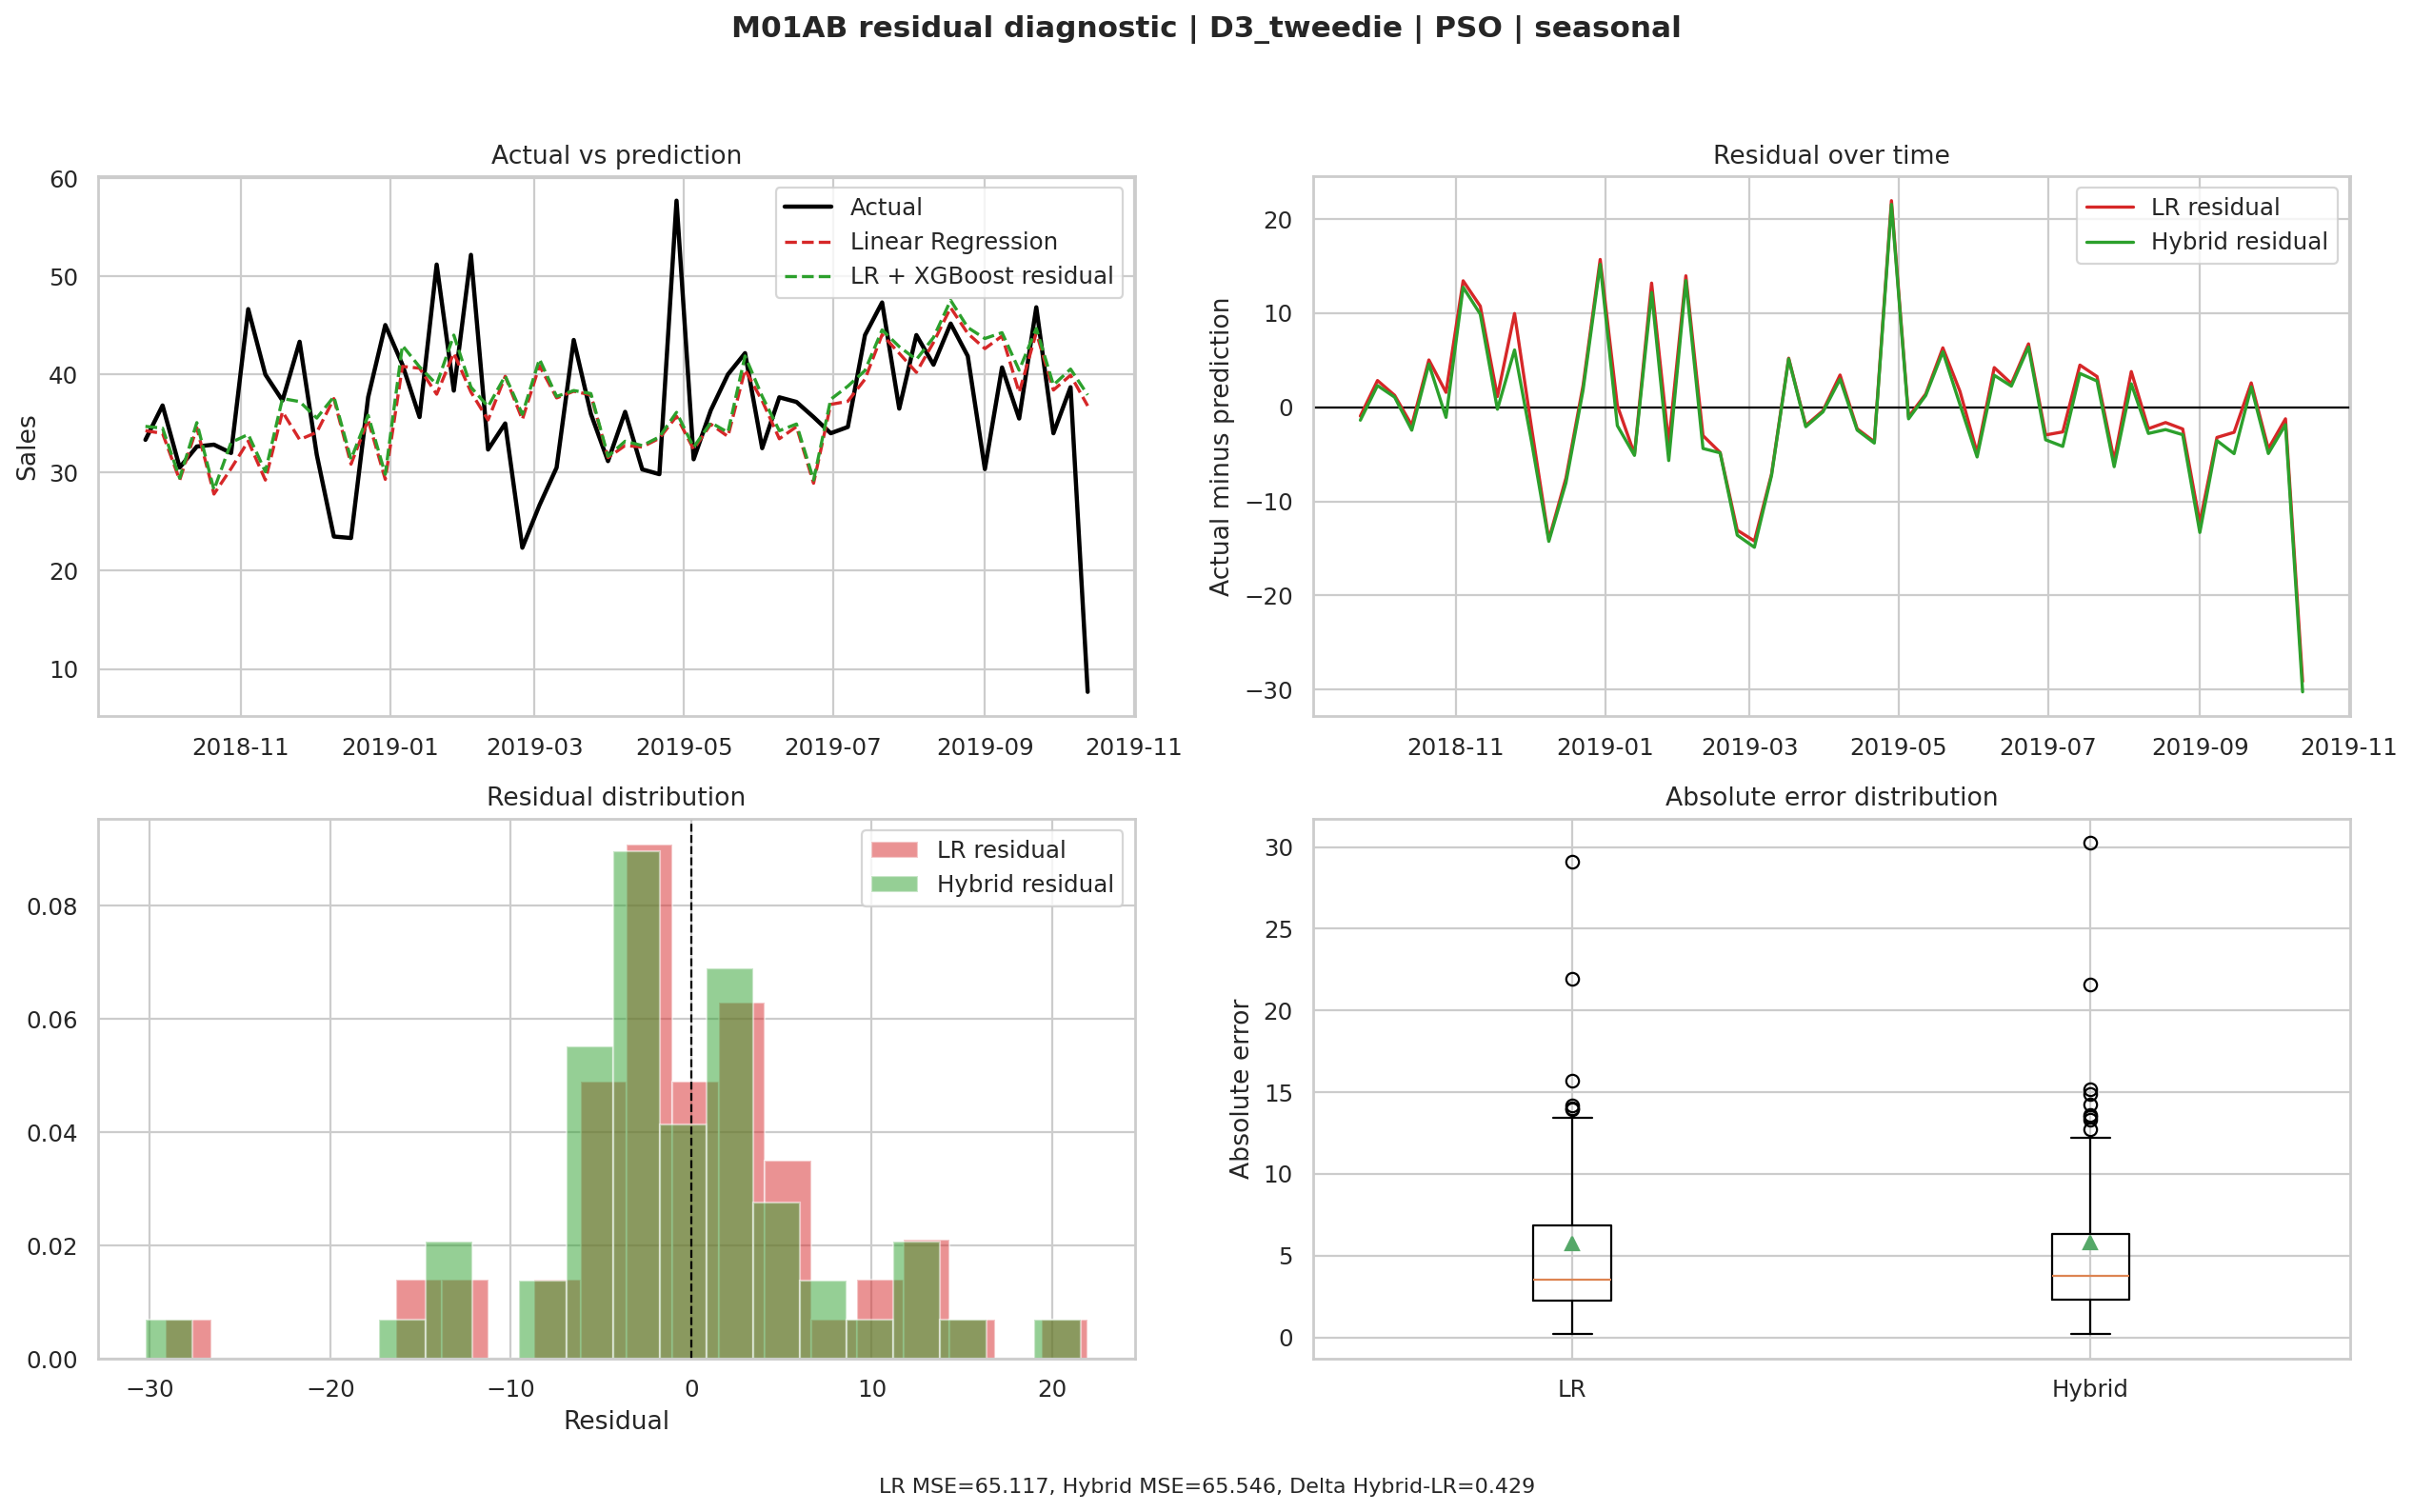

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/M01AB_residual_diagnostic.png


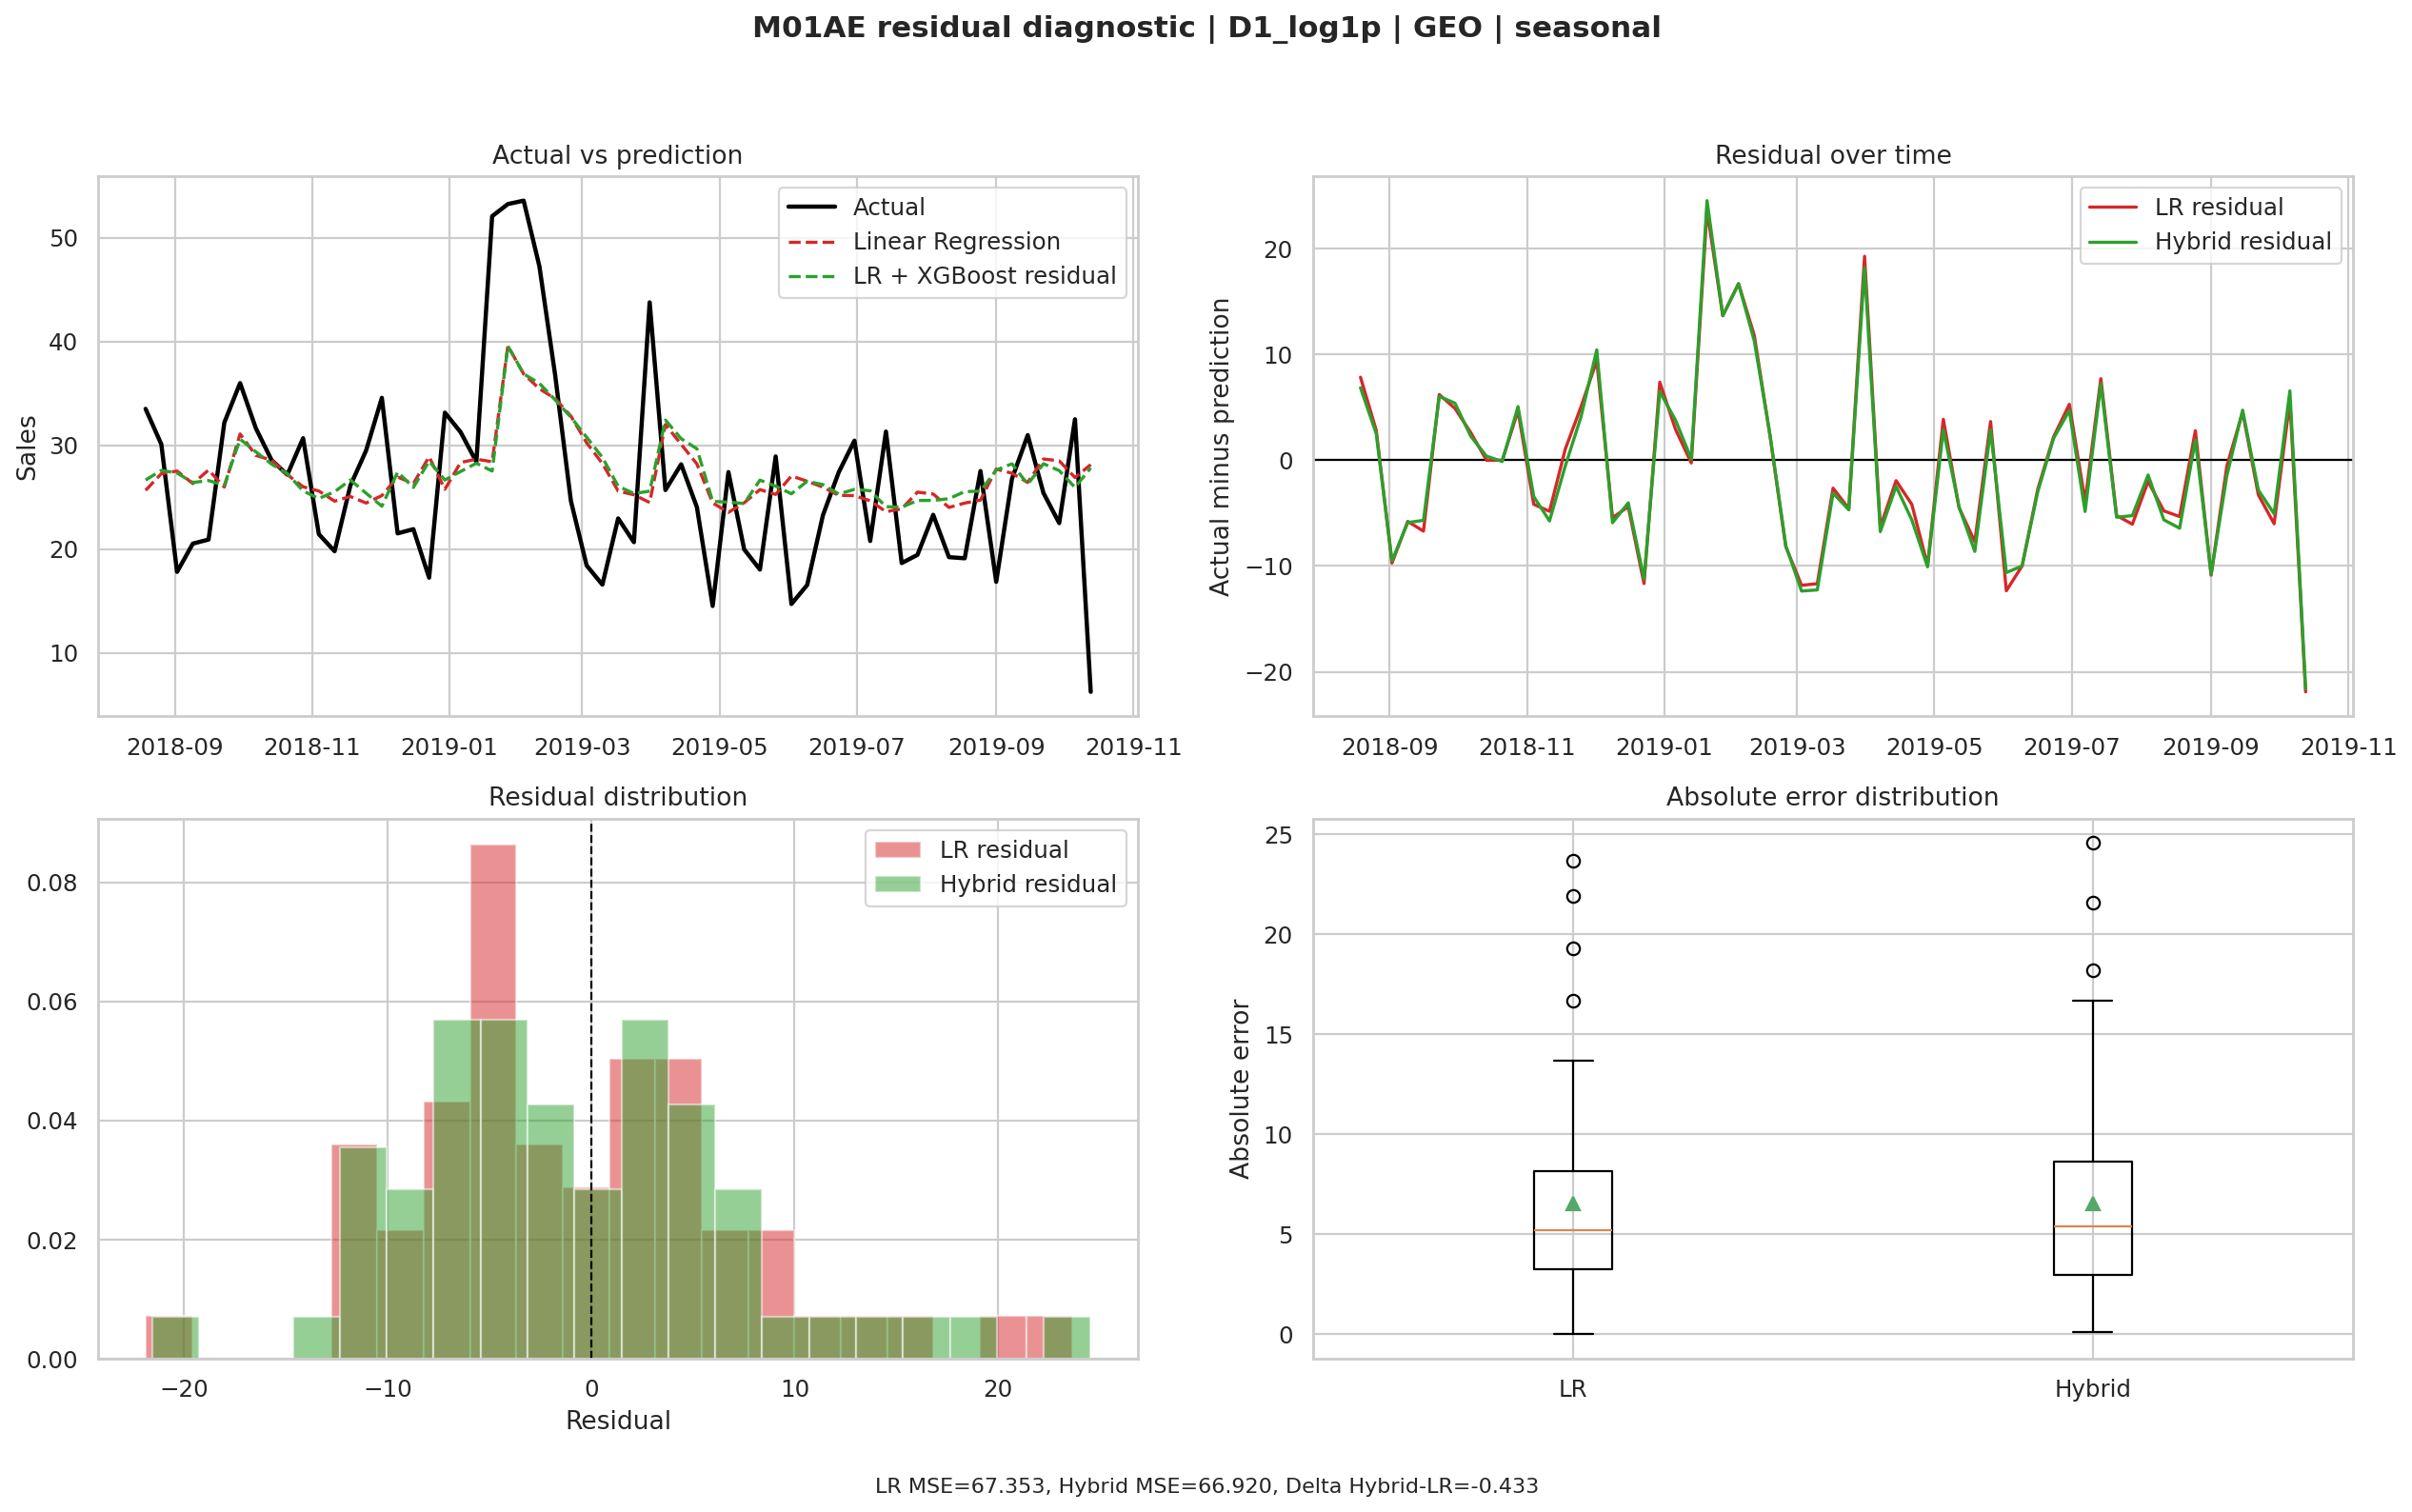

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/M01AE_residual_diagnostic.png


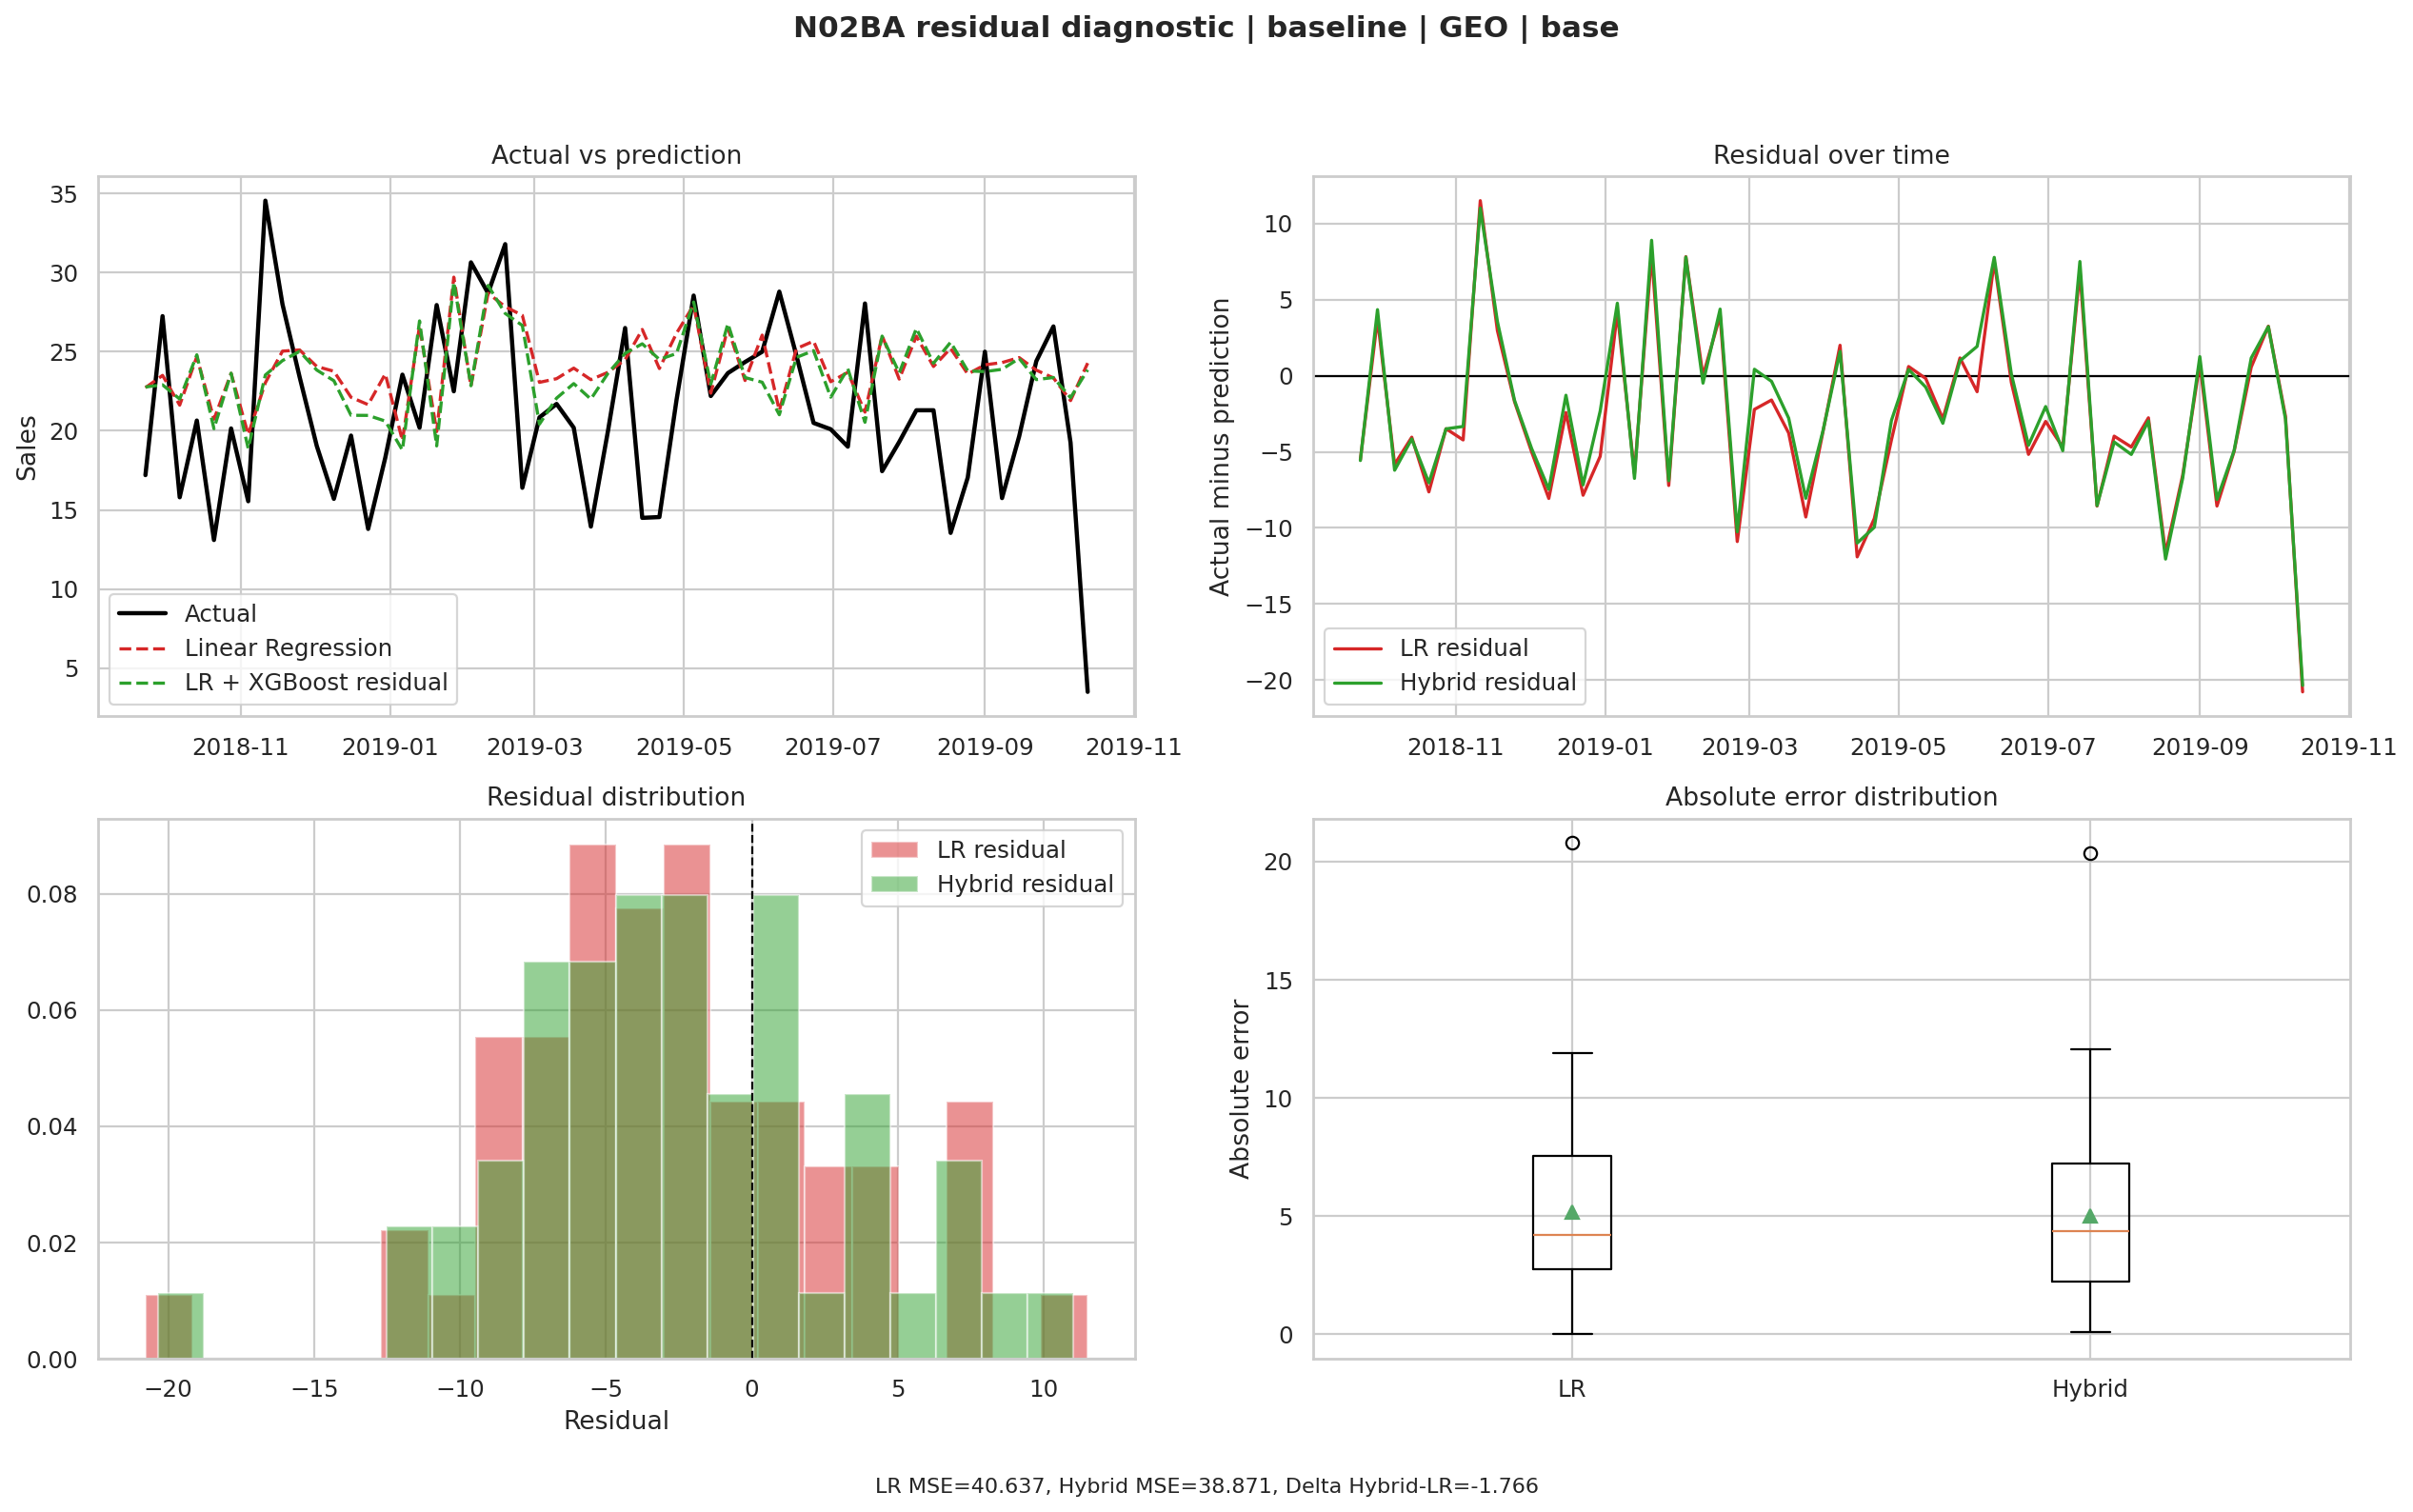

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N02BA_residual_diagnostic.png


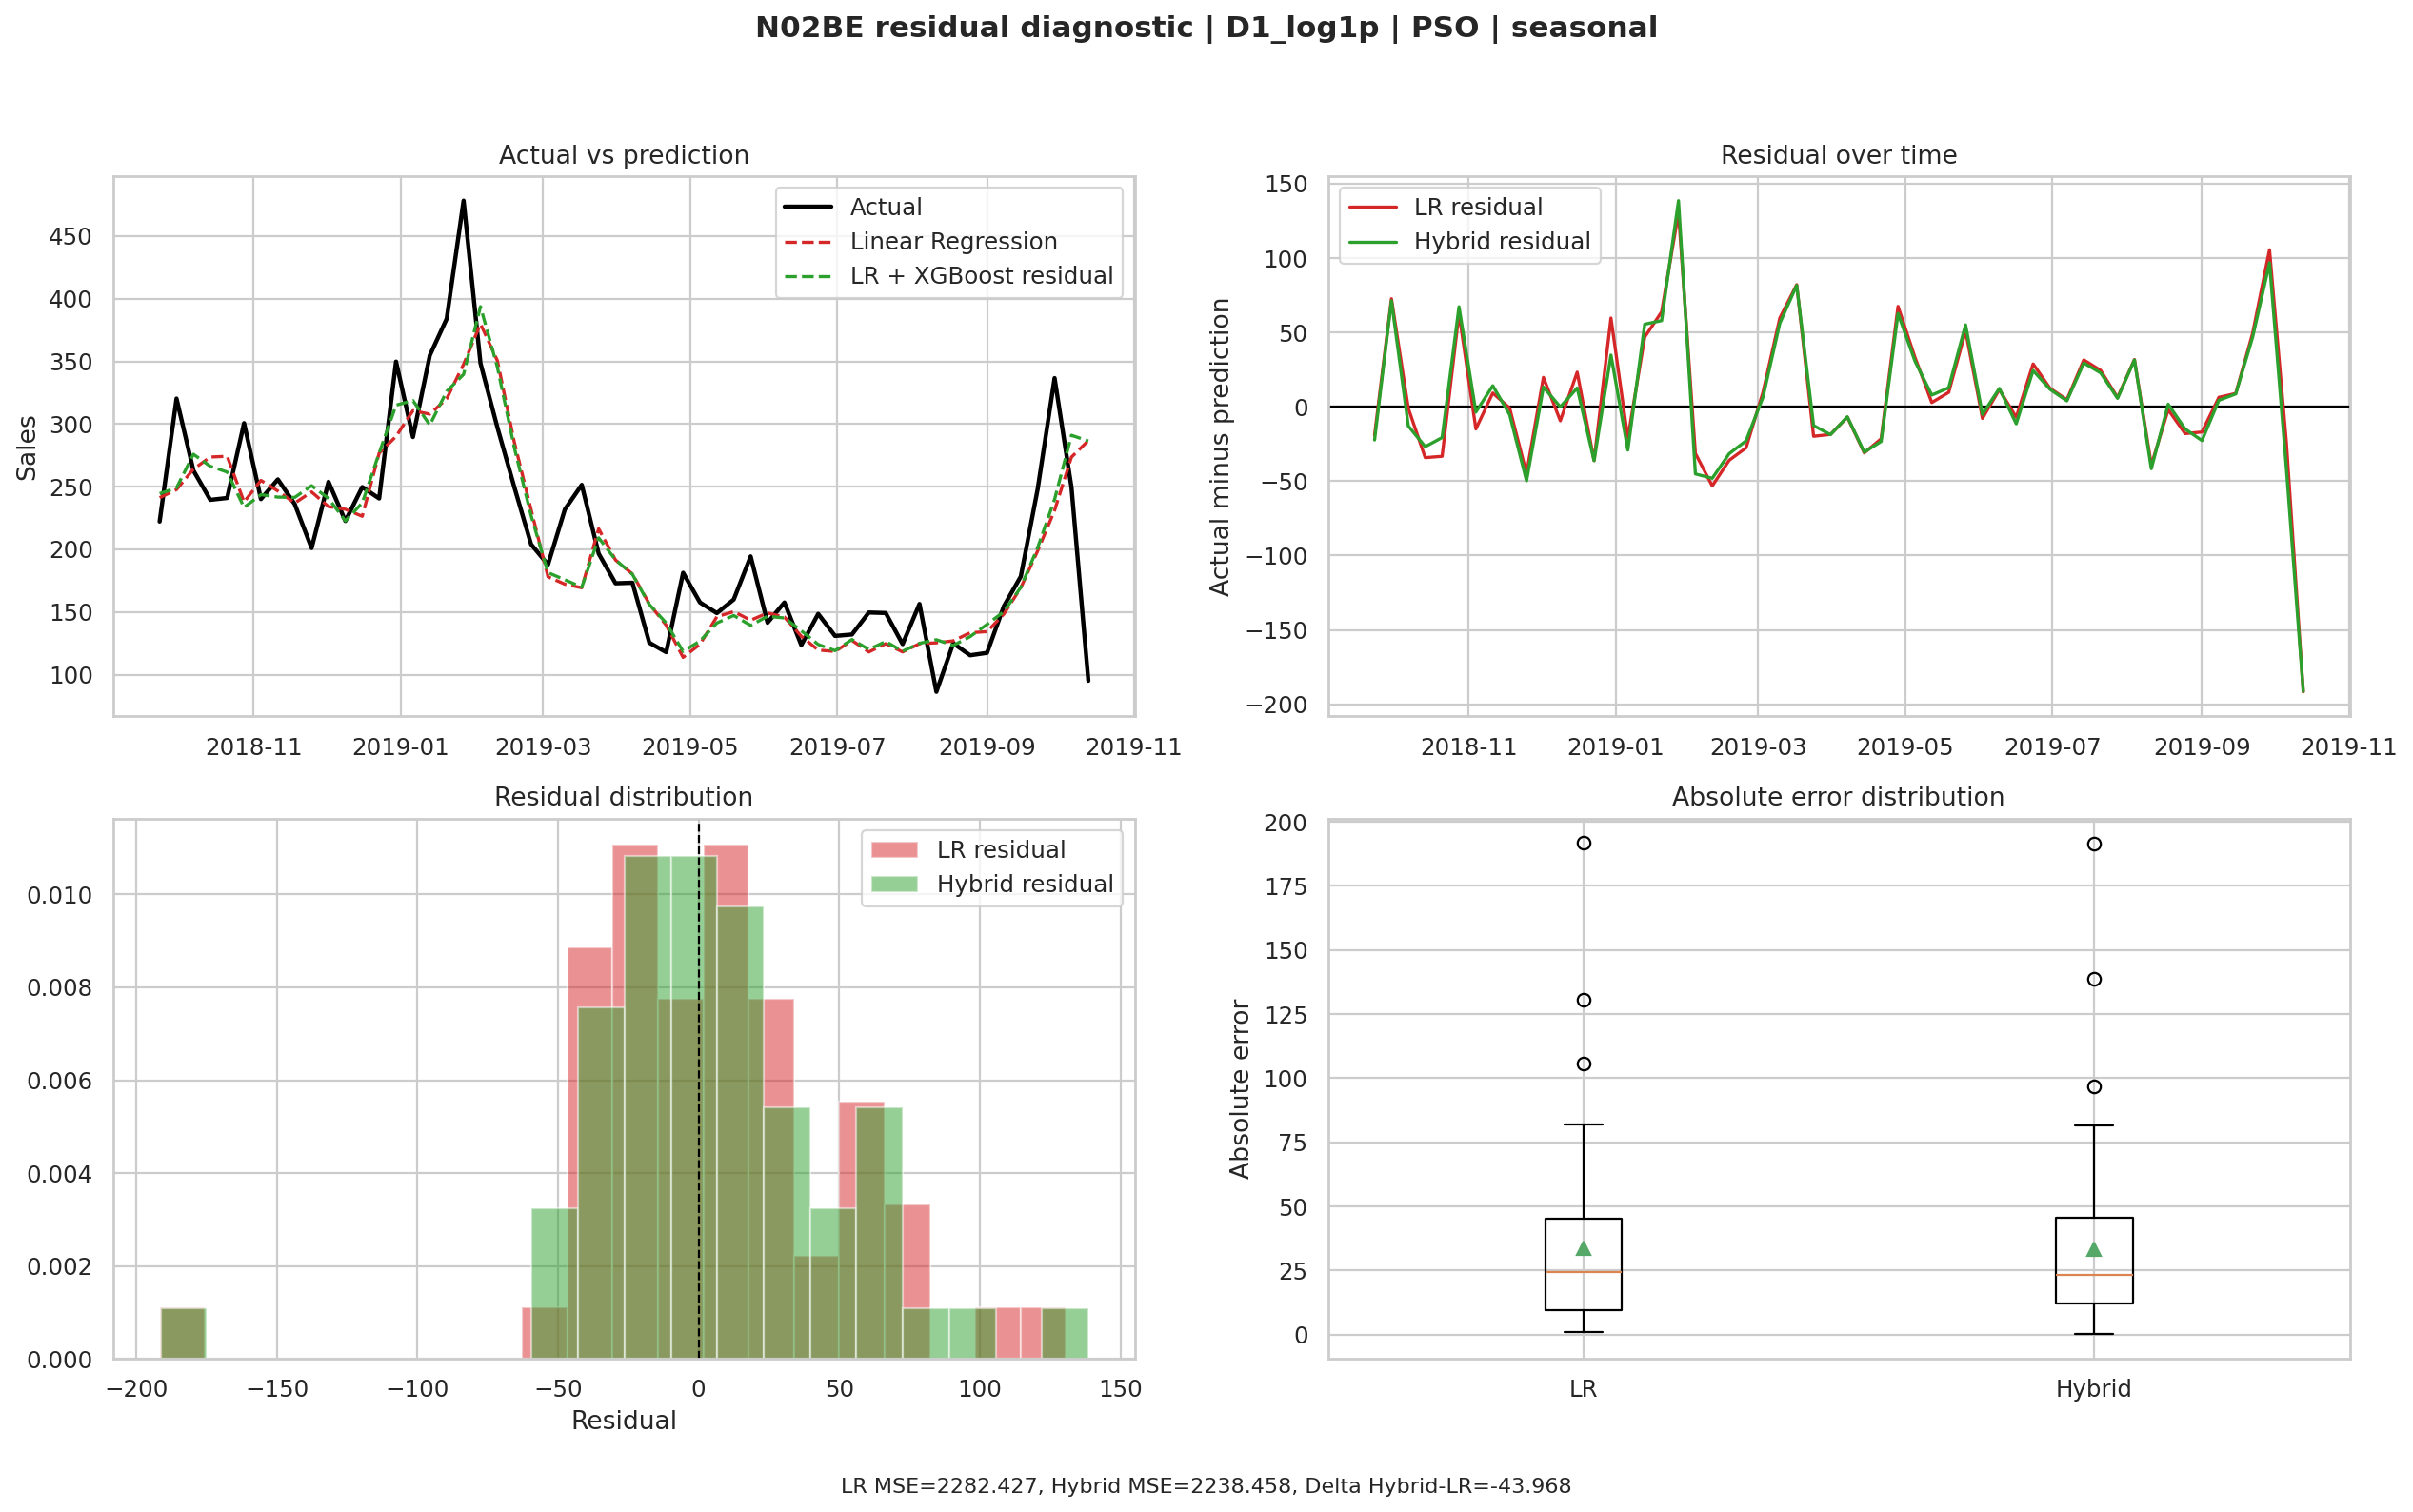

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N02BE_residual_diagnostic.png


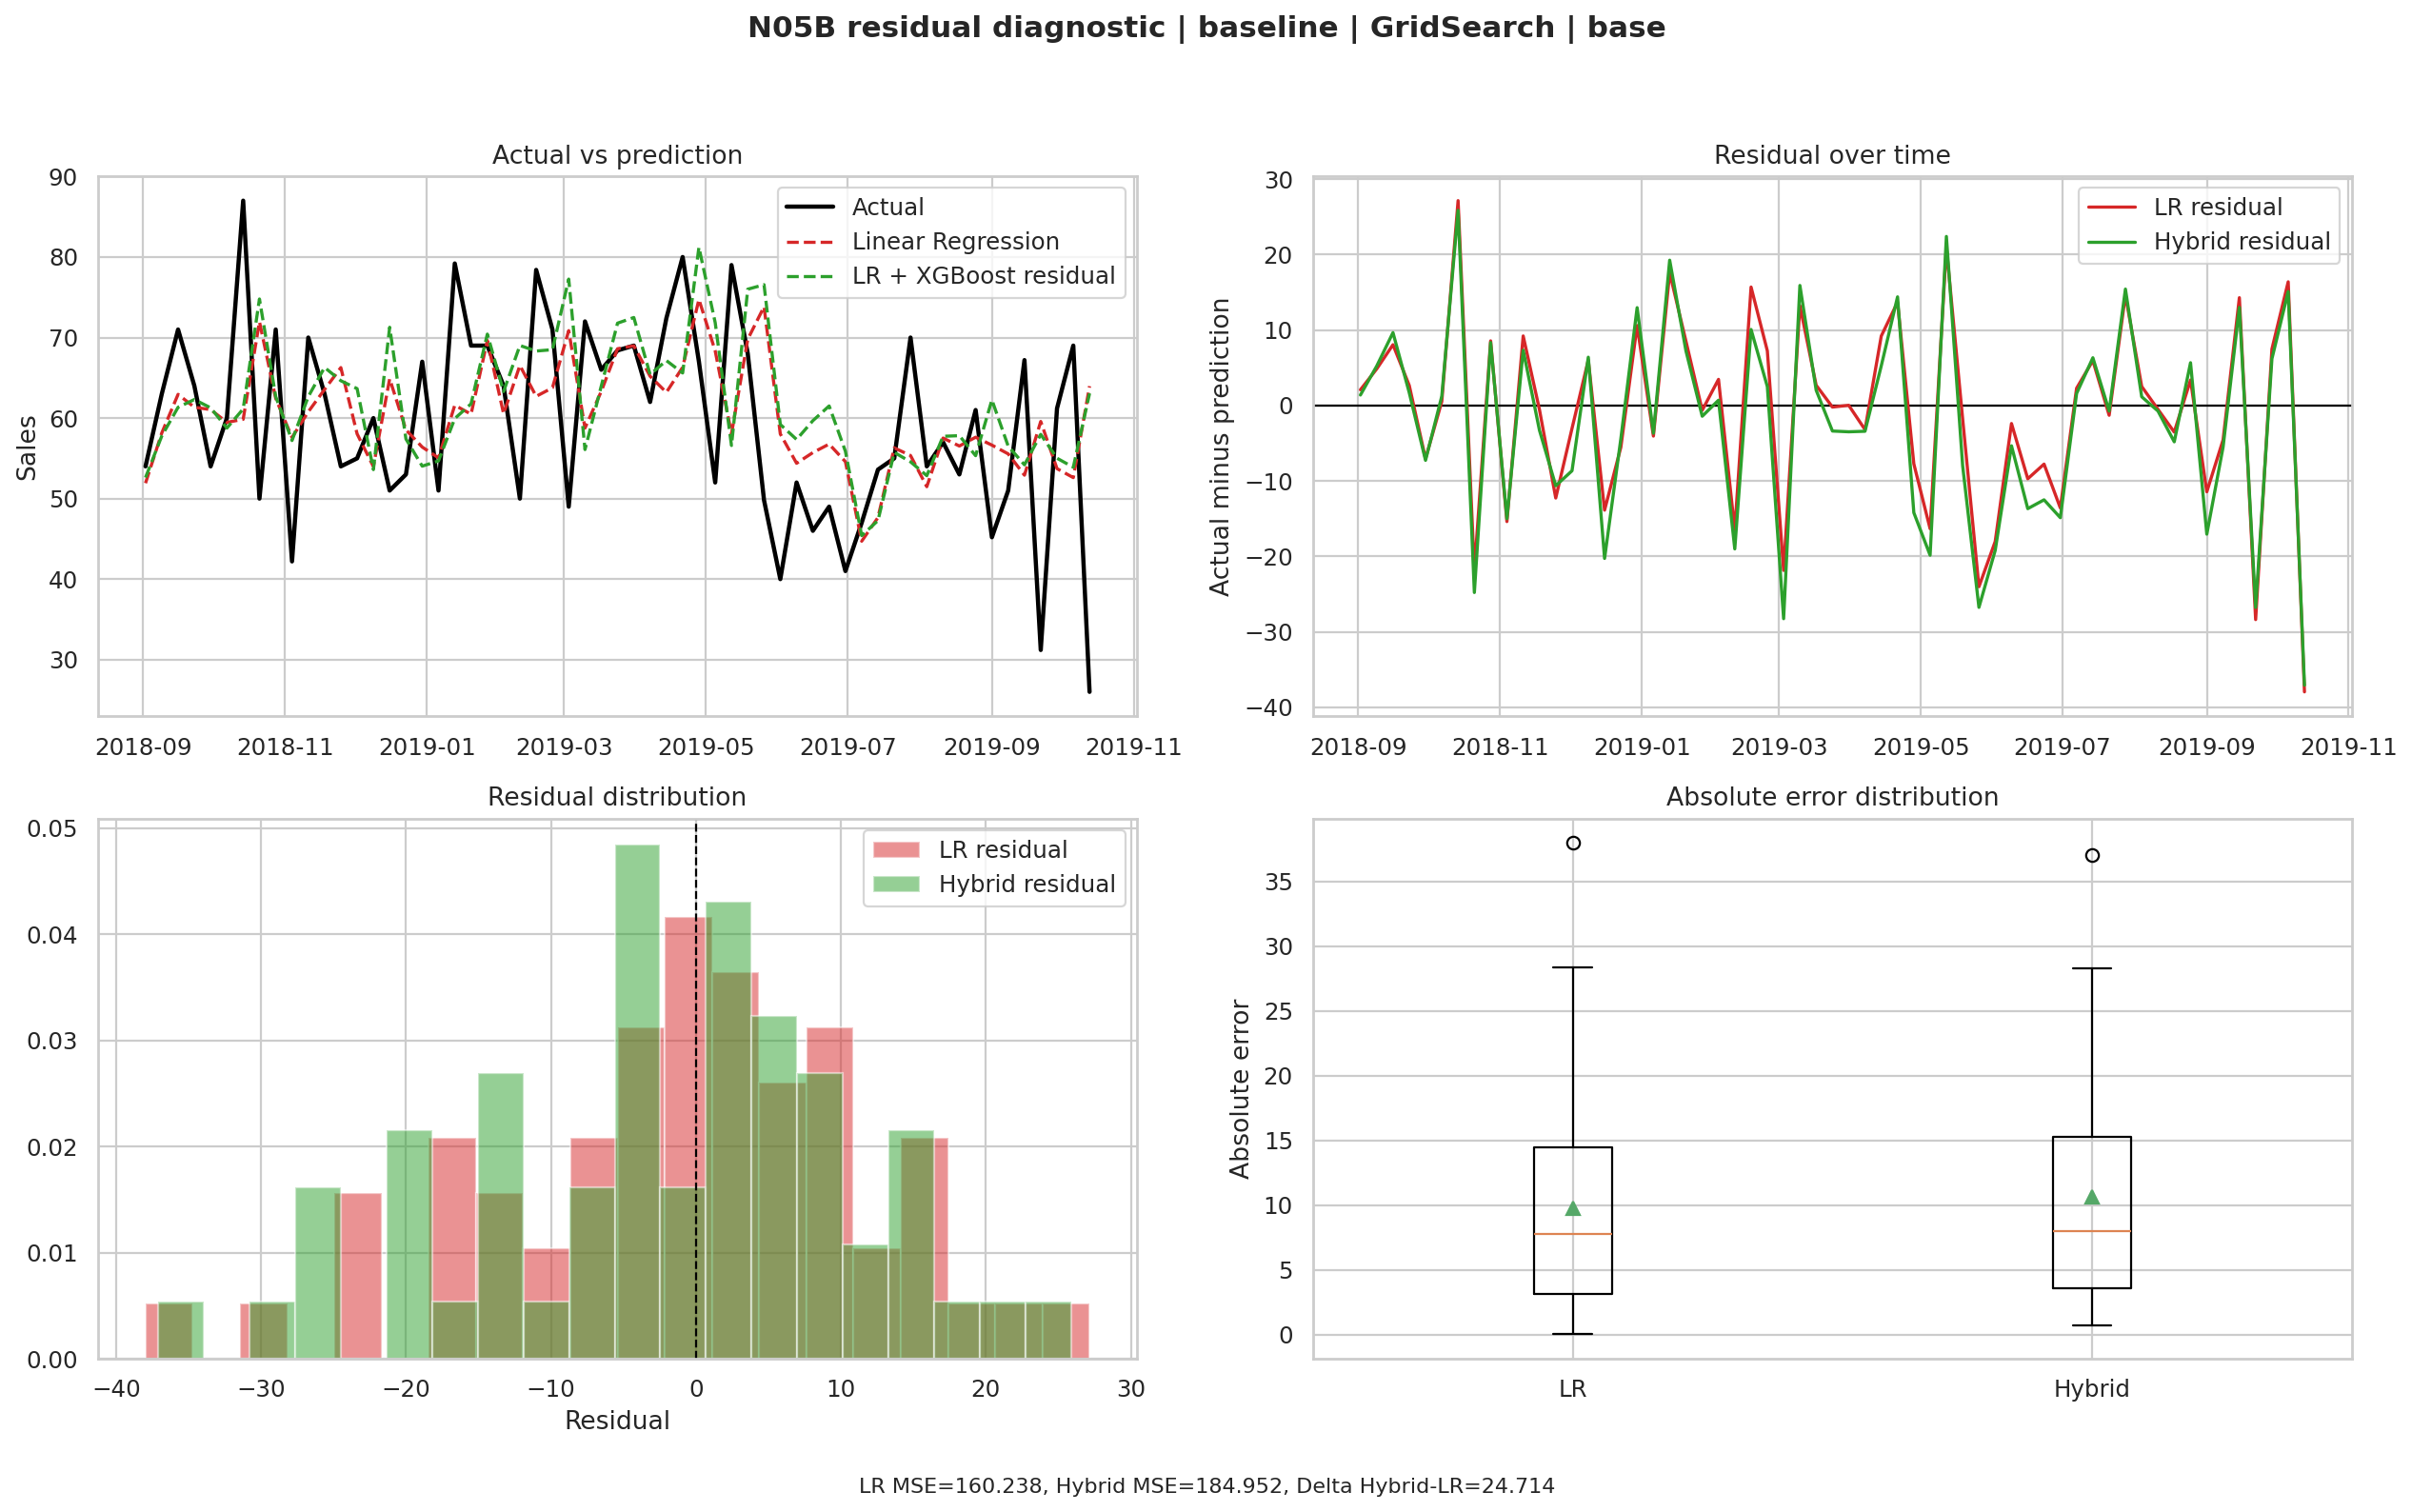

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N05B_residual_diagnostic.png


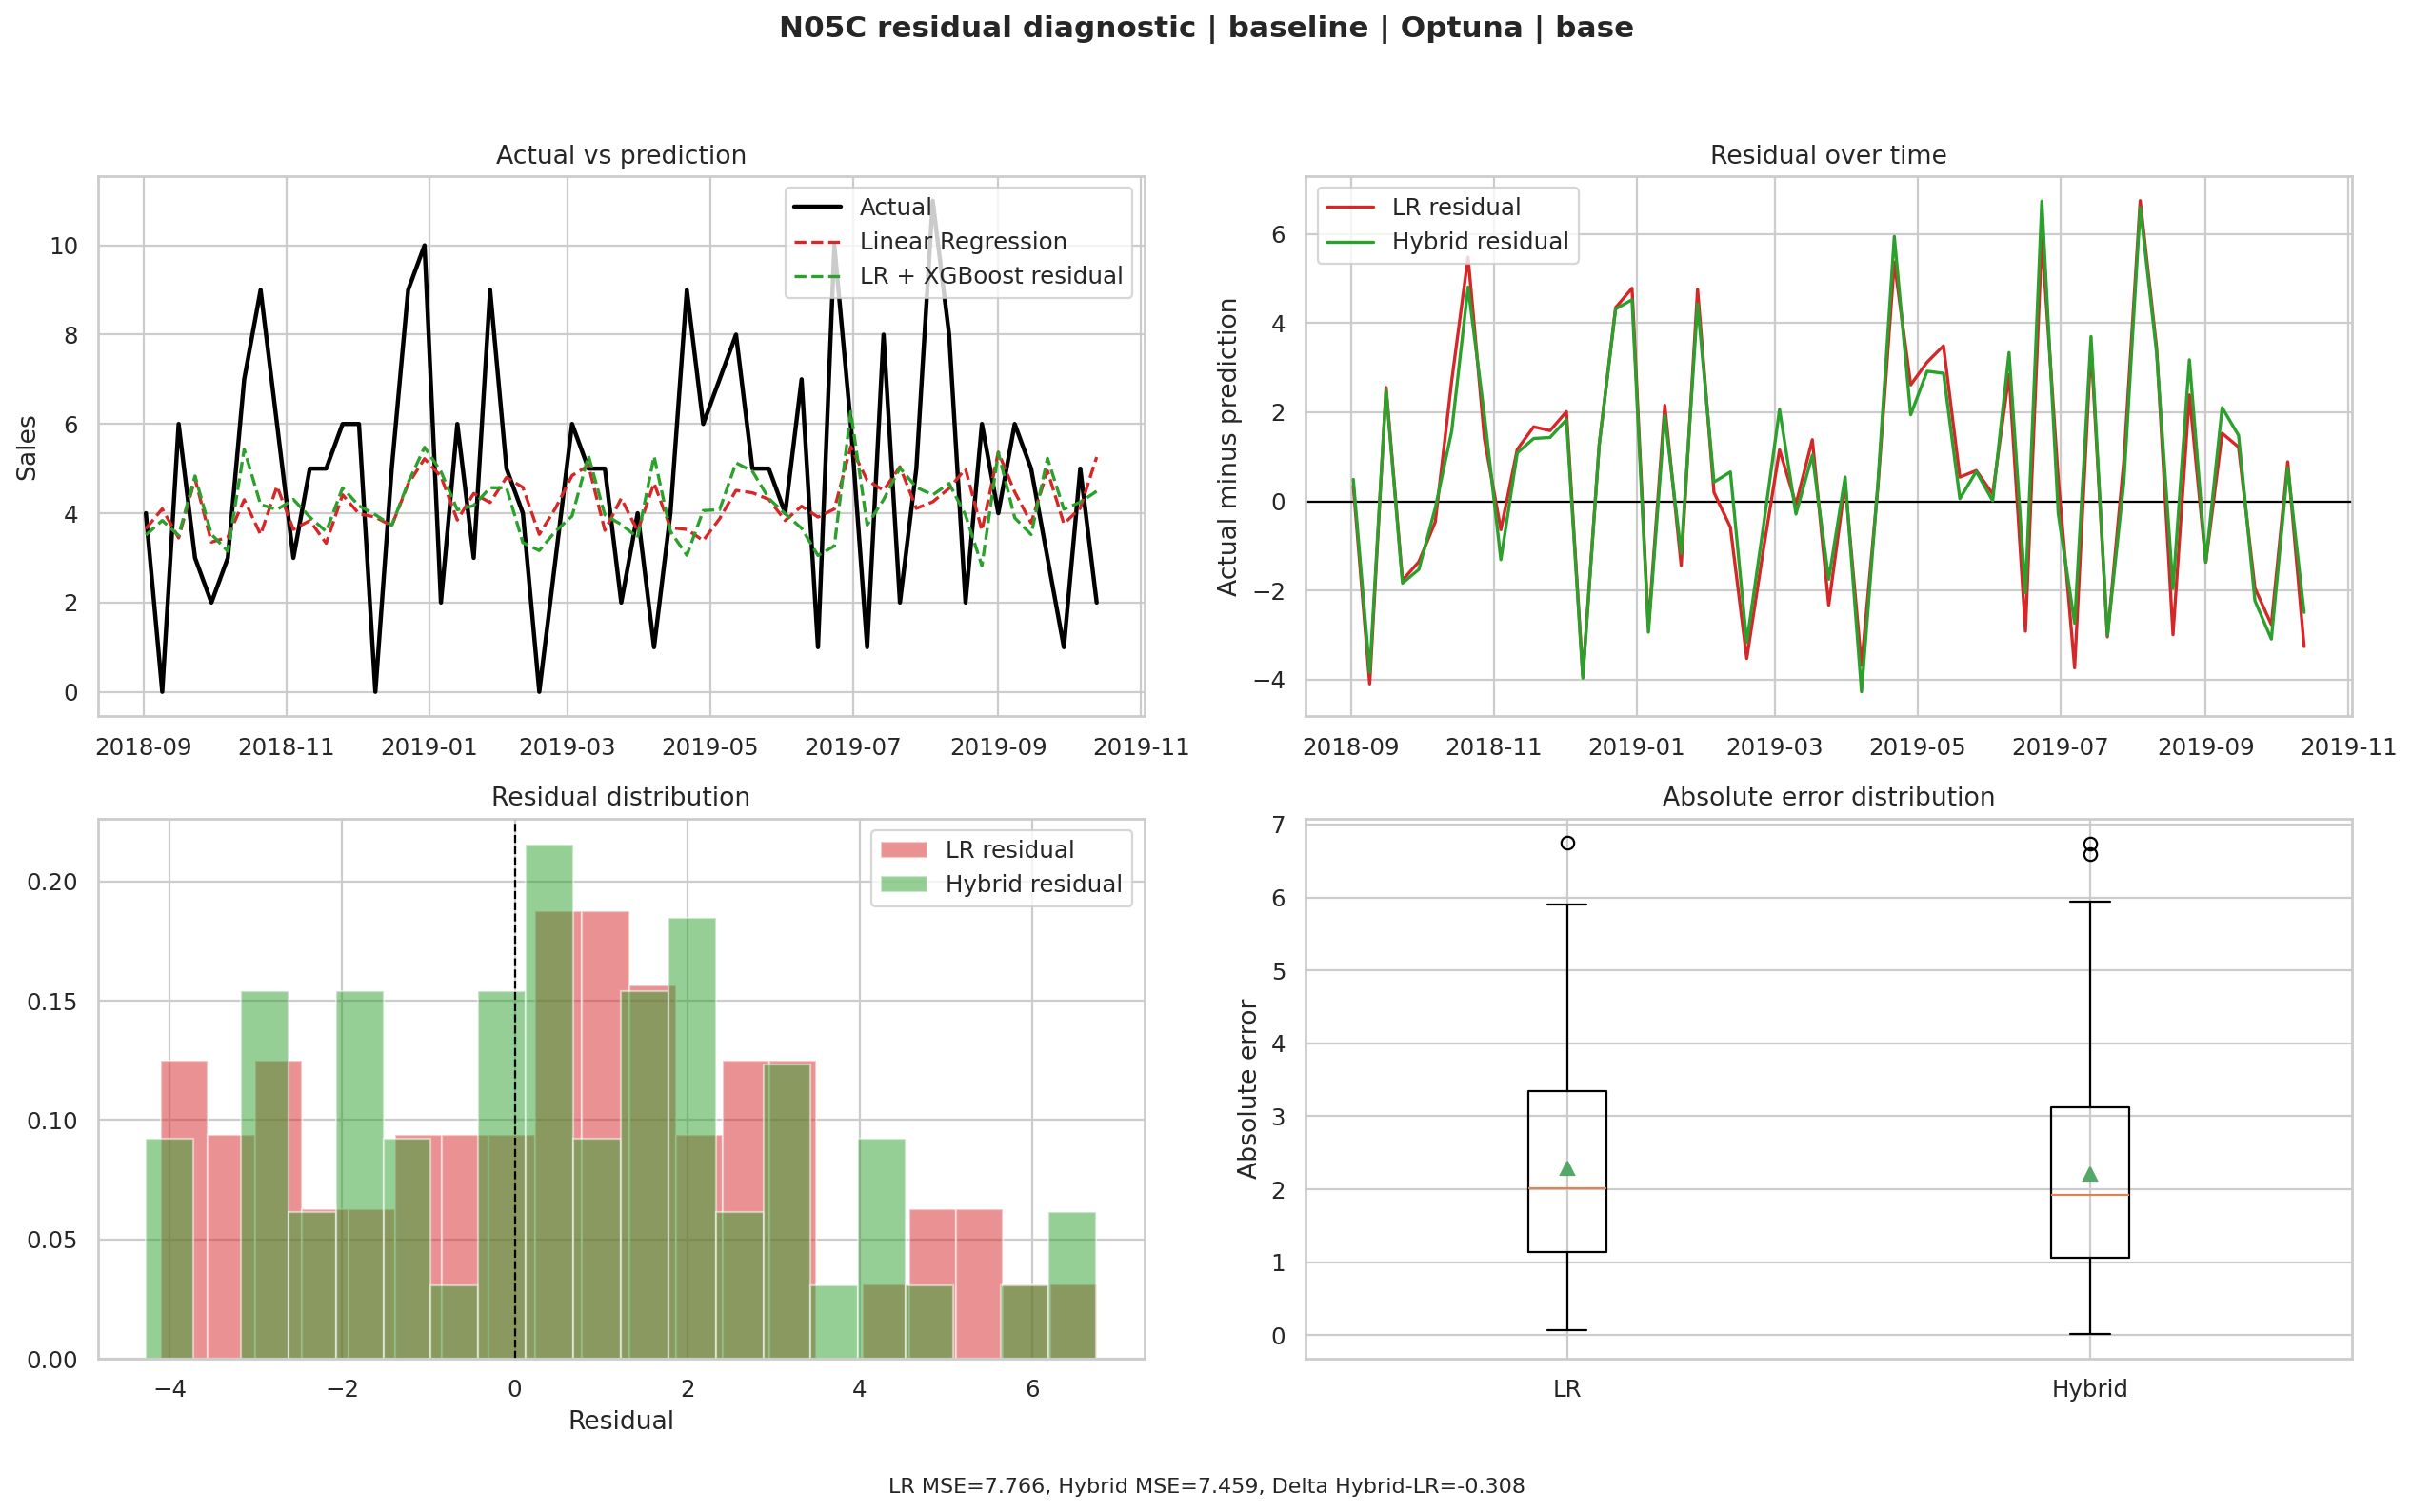

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N05C_residual_diagnostic.png


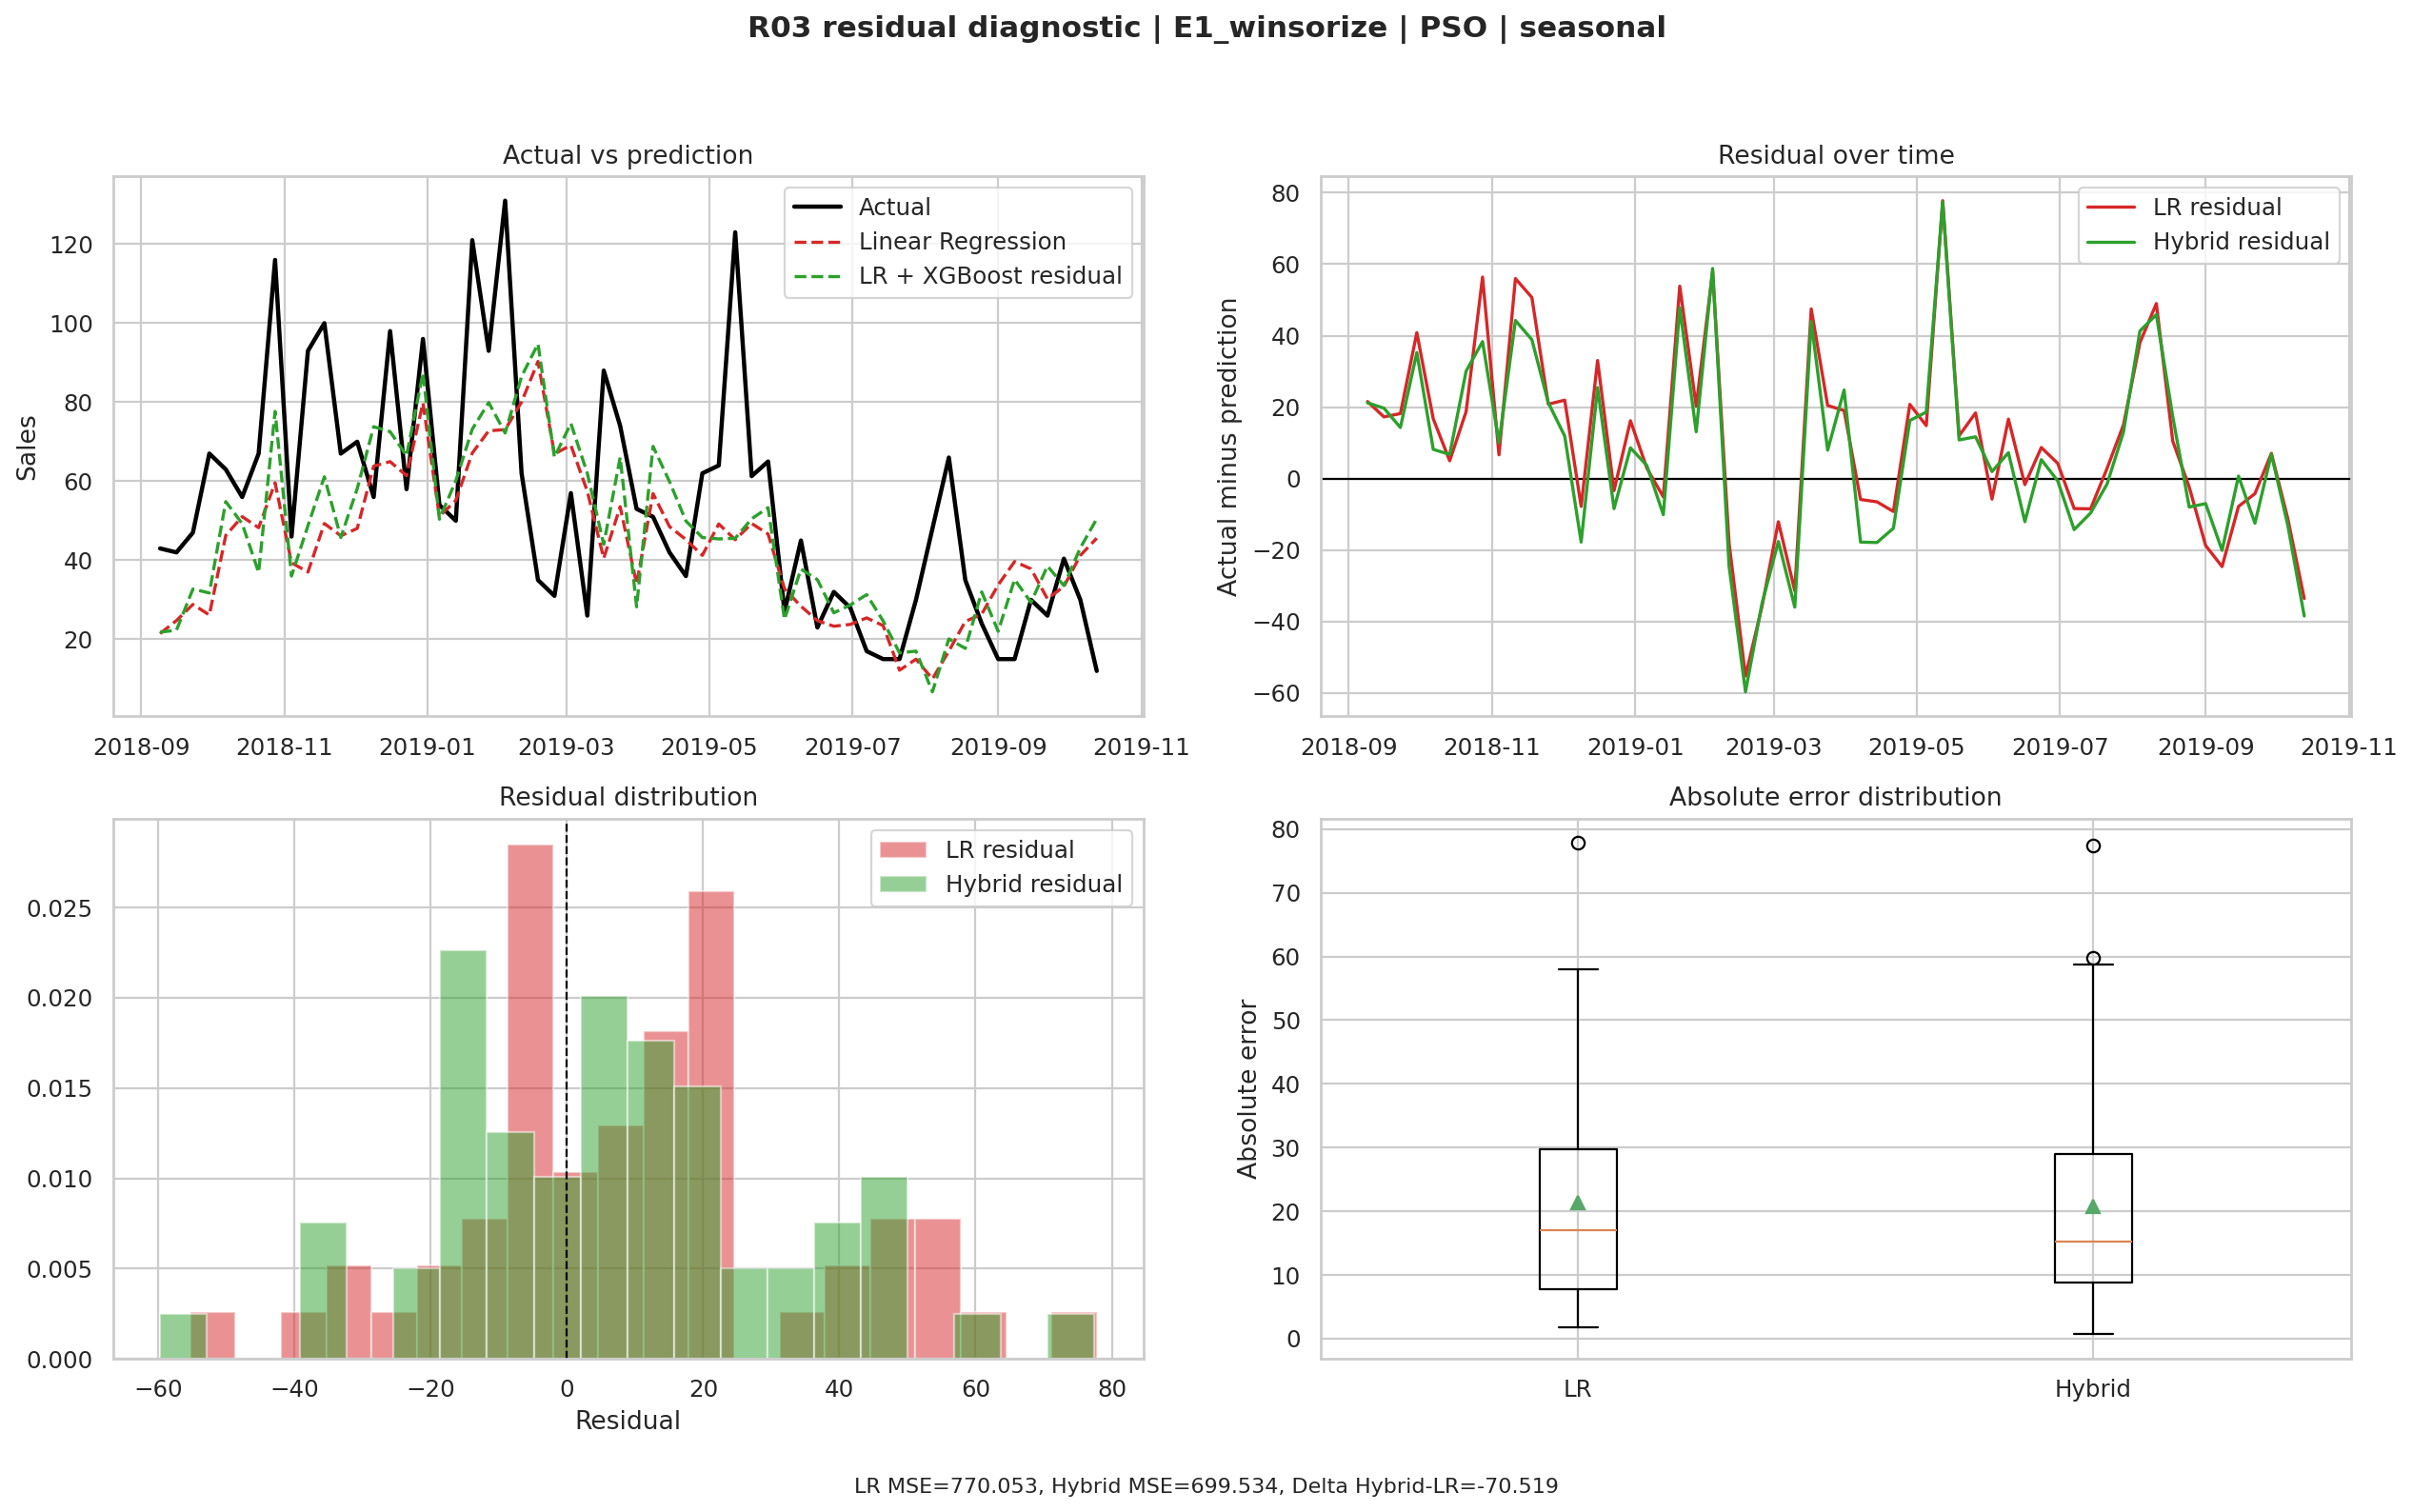

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/R03_residual_diagnostic.png


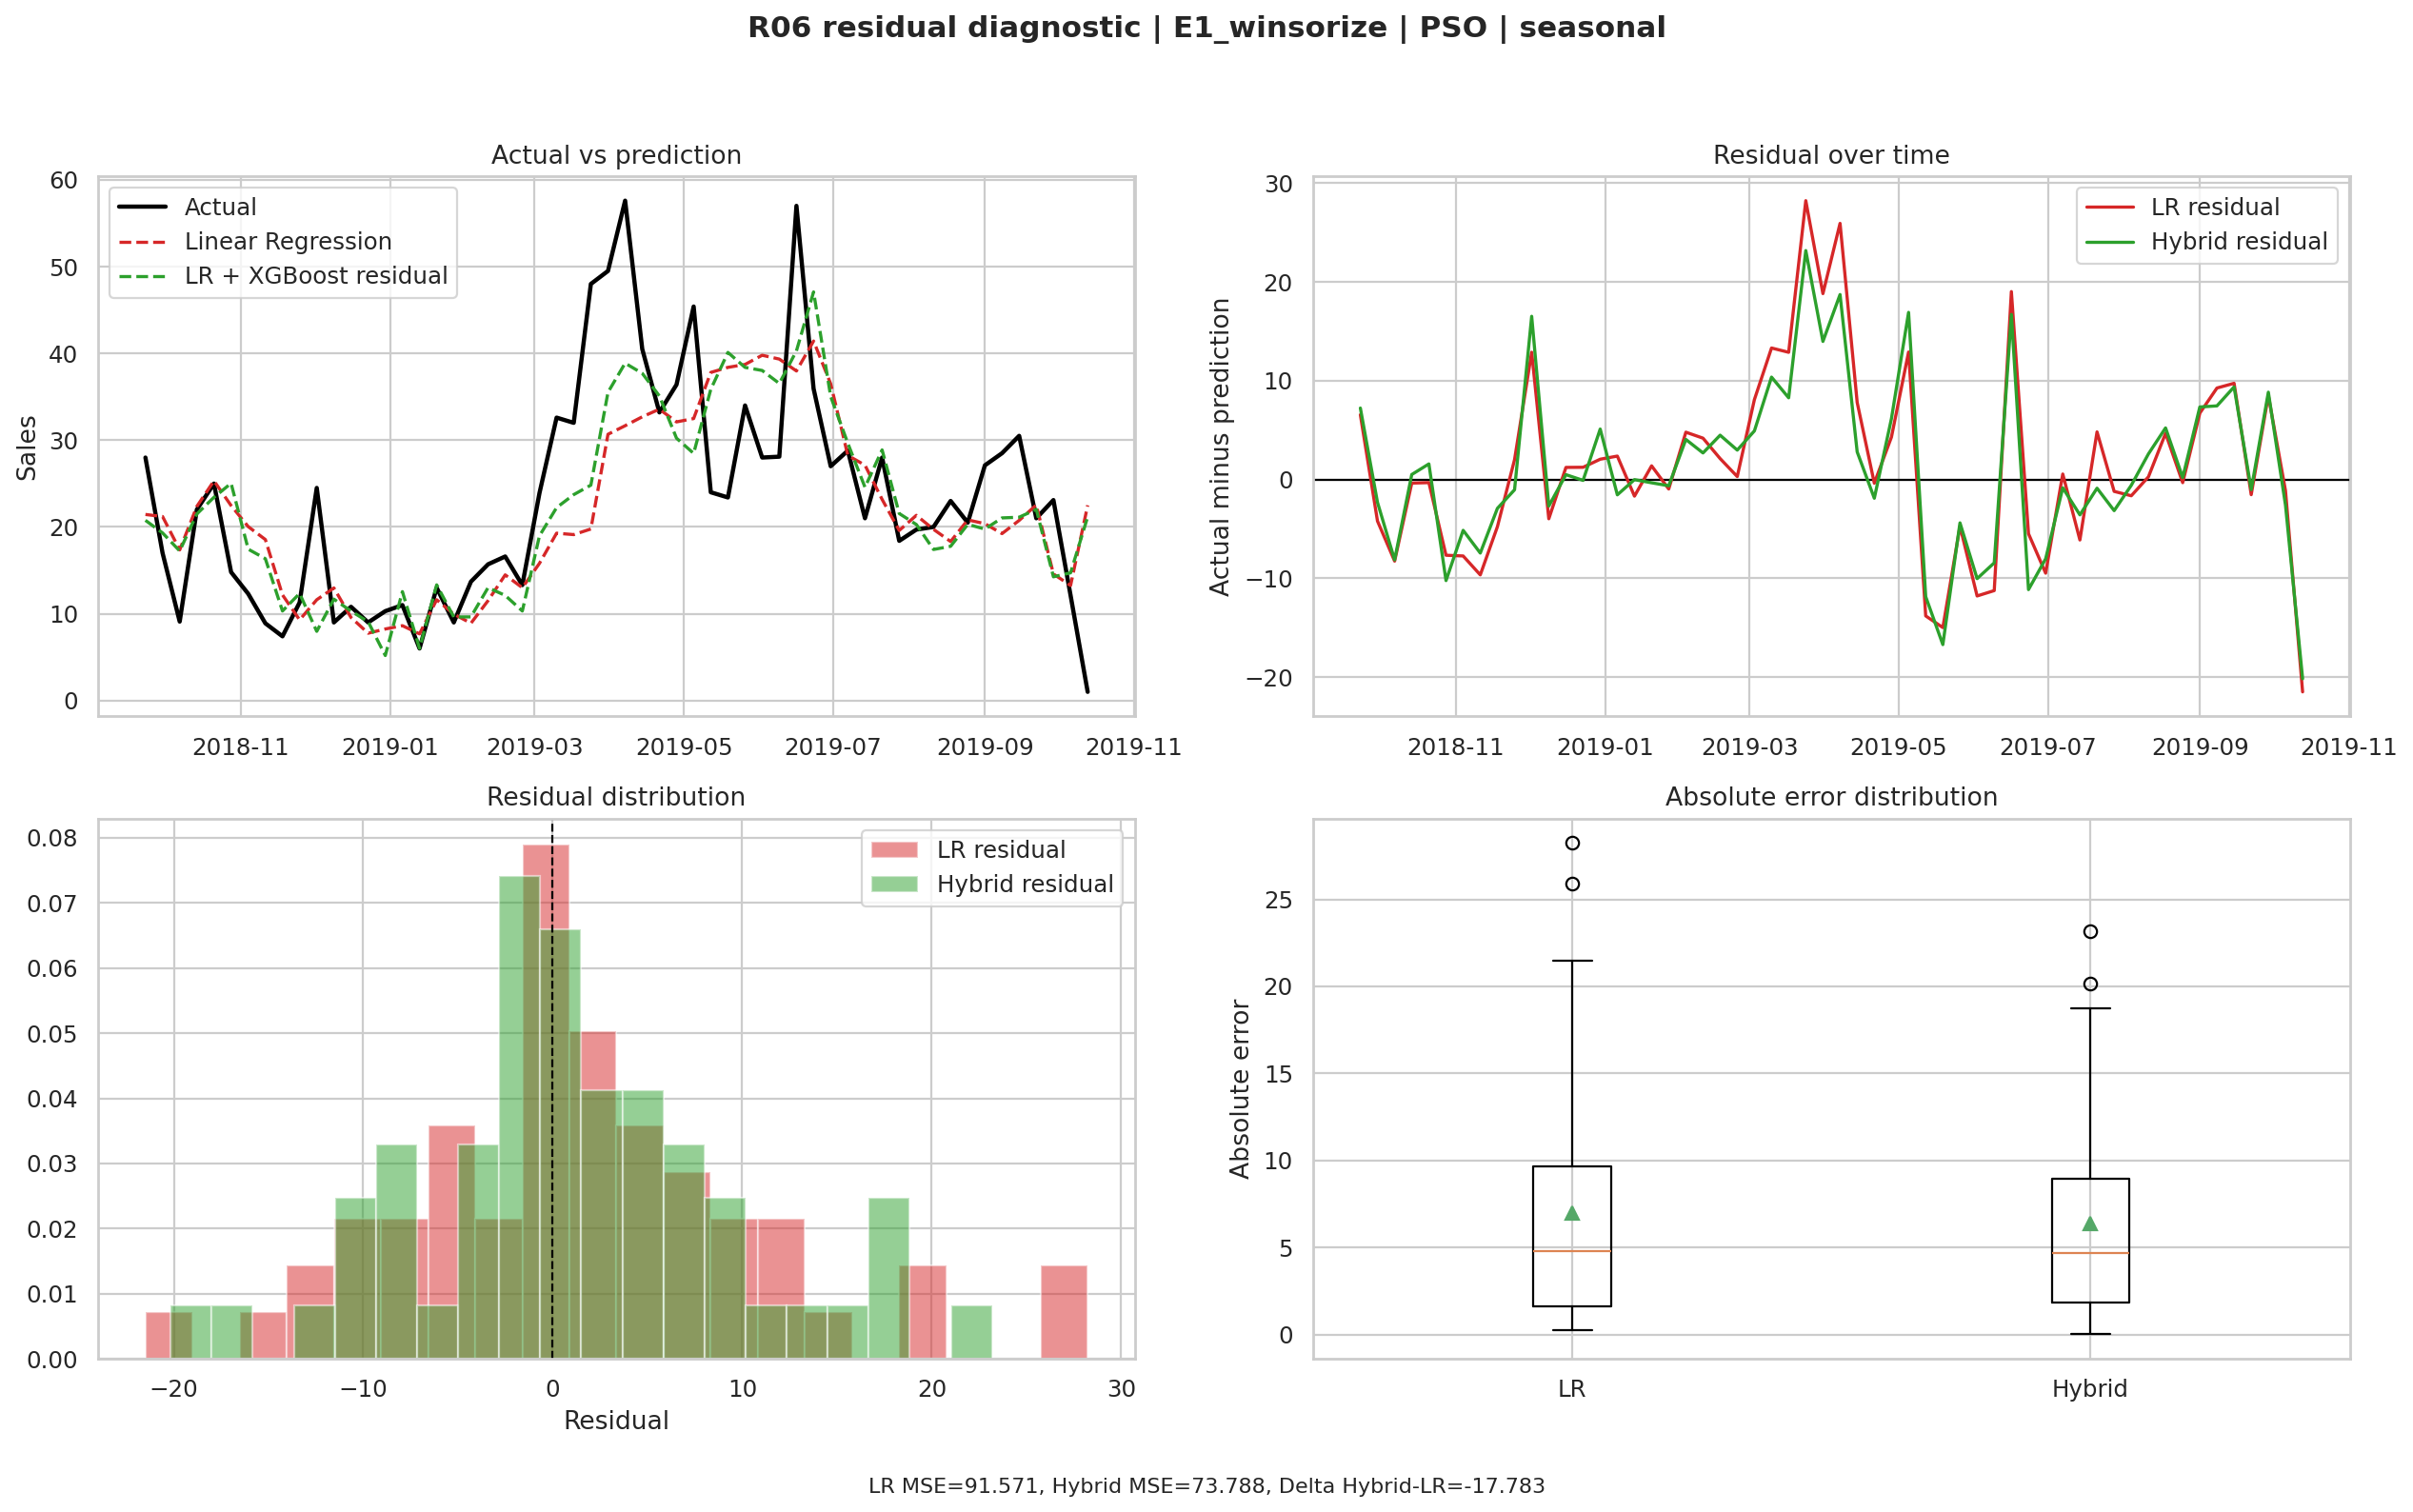

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/R06_residual_diagnostic.png


In [14]:
FIG_DIR = OUTPUT_DIR / 'residual_diagnostics_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Figure dir:', FIG_DIR)


def plot_category_diagnostics(category):
    df = diagnostics_df[diagnostics_df['category'] == category].copy()
    info = best_residual[best_residual['category'] == category].iloc[0]
    m = diagnostic_metrics[diagnostic_metrics['category'] == category].iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=160)
    fig.suptitle(
        f'{category} residual diagnostic | {info["experiment"]} | {info["optimizer"]} | {info["feature_set"]}',
        fontsize=14,
        fontweight='bold',
    )

    ax = axes[0, 0]
    ax.plot(df['ds'], df['actual'], label='Actual', color='black', linewidth=2)
    ax.plot(df['ds'], df['lr_pred'], label='Linear Regression', color='#d62728', linestyle='--')
    ax.plot(df['ds'], df['hybrid_pred'], label='LR + XGBoost residual', color='#2ca02c', linestyle='--')
    ax.set_title('Actual vs prediction')
    ax.set_ylabel('Sales')
    ax.legend()

    ax = axes[0, 1]
    ax.axhline(0, color='black', linewidth=1)
    ax.plot(df['ds'], df['lr_residual'], label='LR residual', color='#d62728')
    ax.plot(df['ds'], df['hybrid_residual'], label='Hybrid residual', color='#2ca02c')
    ax.set_title('Residual over time')
    ax.set_ylabel('Actual minus prediction')
    ax.legend()

    ax = axes[1, 0]
    ax.hist(df['lr_residual'], bins=20, alpha=0.5, label='LR residual', color='#d62728', density=True)
    ax.hist(df['hybrid_residual'], bins=20, alpha=0.5, label='Hybrid residual', color='#2ca02c', density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Residual distribution')
    ax.set_xlabel('Residual')
    ax.legend()

    ax = axes[1, 1]
    ax.boxplot([df['lr_abs_error'], df['hybrid_abs_error']], labels=['LR', 'Hybrid'], showmeans=True)
    ax.set_title('Absolute error distribution')
    ax.set_ylabel('Absolute error')

    note = (
        f'LR MSE={m["lr_MSE"]:.3f}, Hybrid MSE={m["hybrid_MSE"]:.3f}, '
        f'Delta Hybrid-LR={m["mse_delta_hybrid_minus_lr"]:.3f}'
    )
    fig.text(0.5, 0.01, note, ha='center', fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    out_path = FIG_DIR / f'{category}_residual_diagnostic.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


for category in categories:
    plot_category_diagnostics(category)

# Section 5 — Residual ACF Before and After Correction

ACF residual dipakai untuk melihat apakah sisa error masih punya pola dari waktu ke waktu. Jika residual Linear Regression punya banyak lag yang masih kuat, berarti masih ada pola yang belum ditangkap. Jika setelah residual correction lag tersebut mengecil, berarti XGBoost residual berhasil mengurangi pola error.

Cara membaca plot:

- Jika batang ACF residual hybrid lebih rendah daripada residual Linear Regression, residual correction membantu mengurangi pola error.
- Jika batang ACF hybrid tetap tinggi, residual correction belum menangkap pola error dengan baik.
- Jika residual Linear Regression sejak awal tidak punya pola yang jelas, maka residual correction biasanya sulit membantu karena yang tersisa lebih mirip noise.

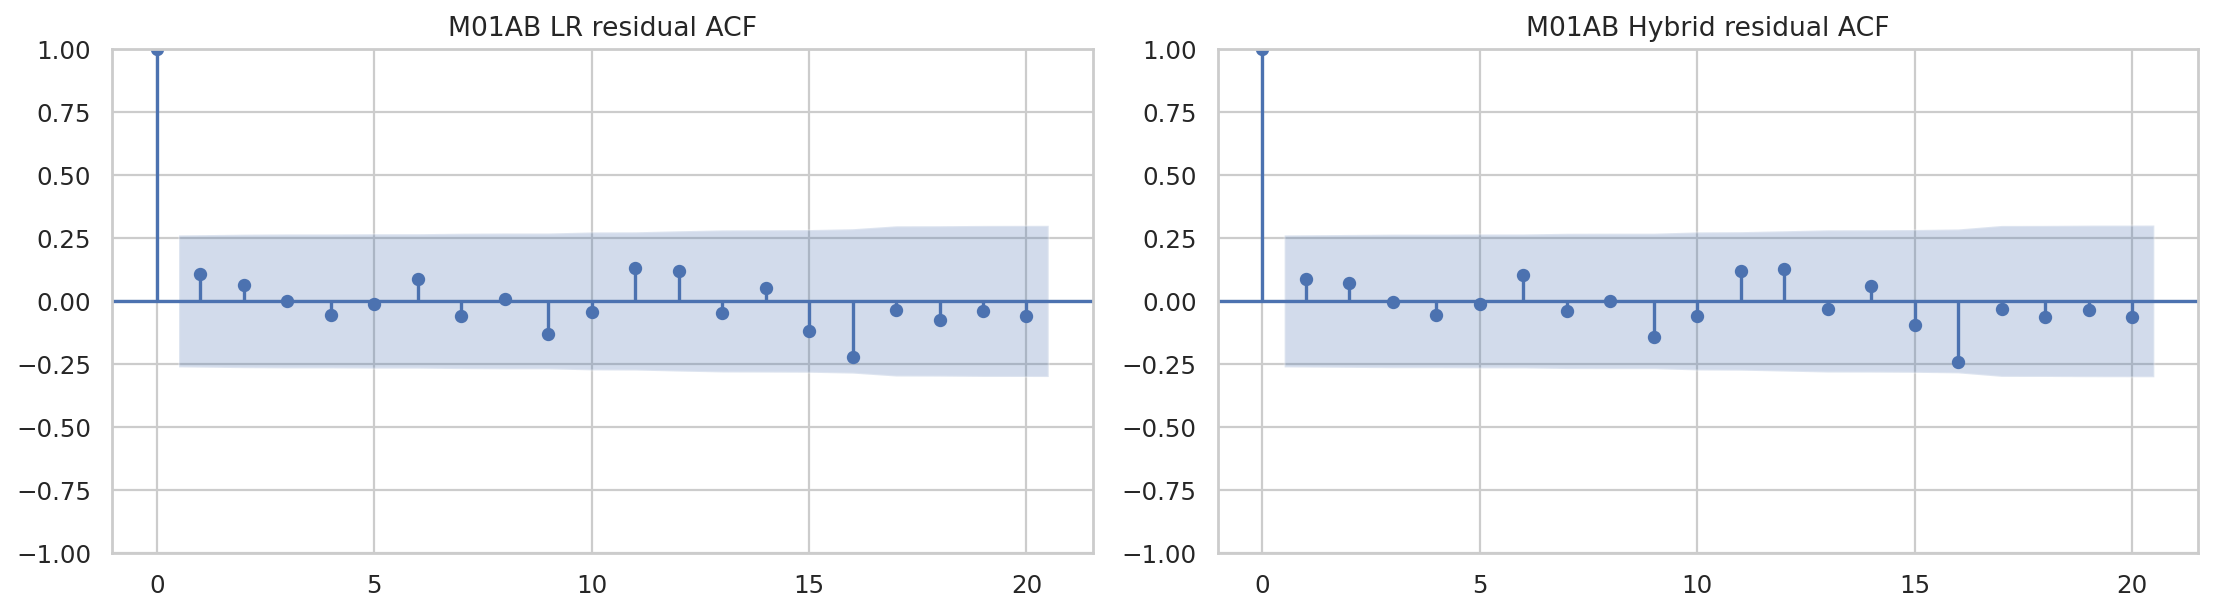

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/M01AB_residual_acf_before_after.png


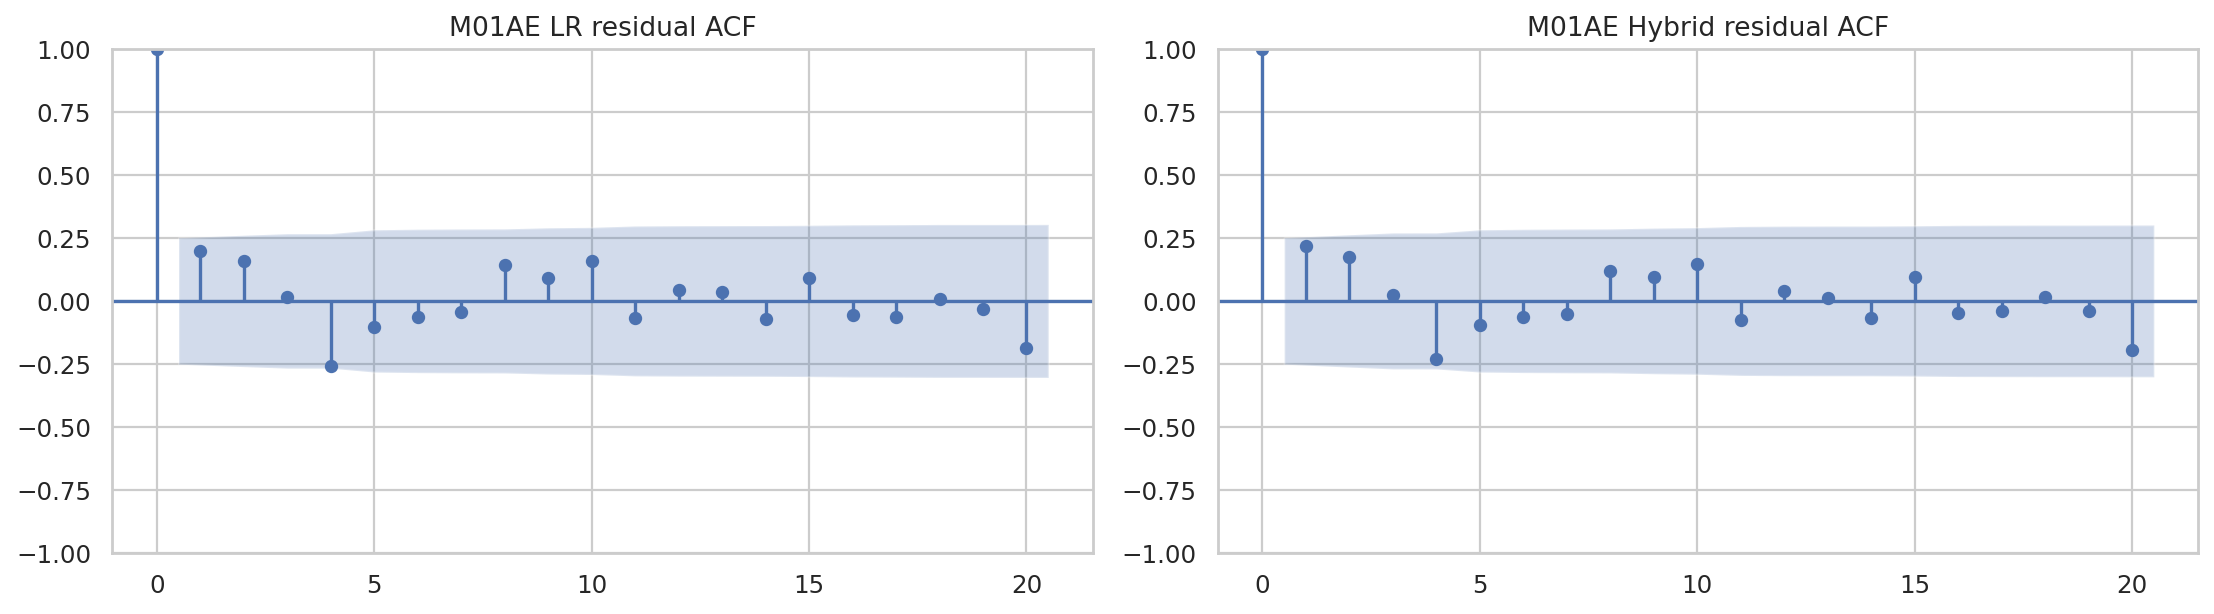

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/M01AE_residual_acf_before_after.png


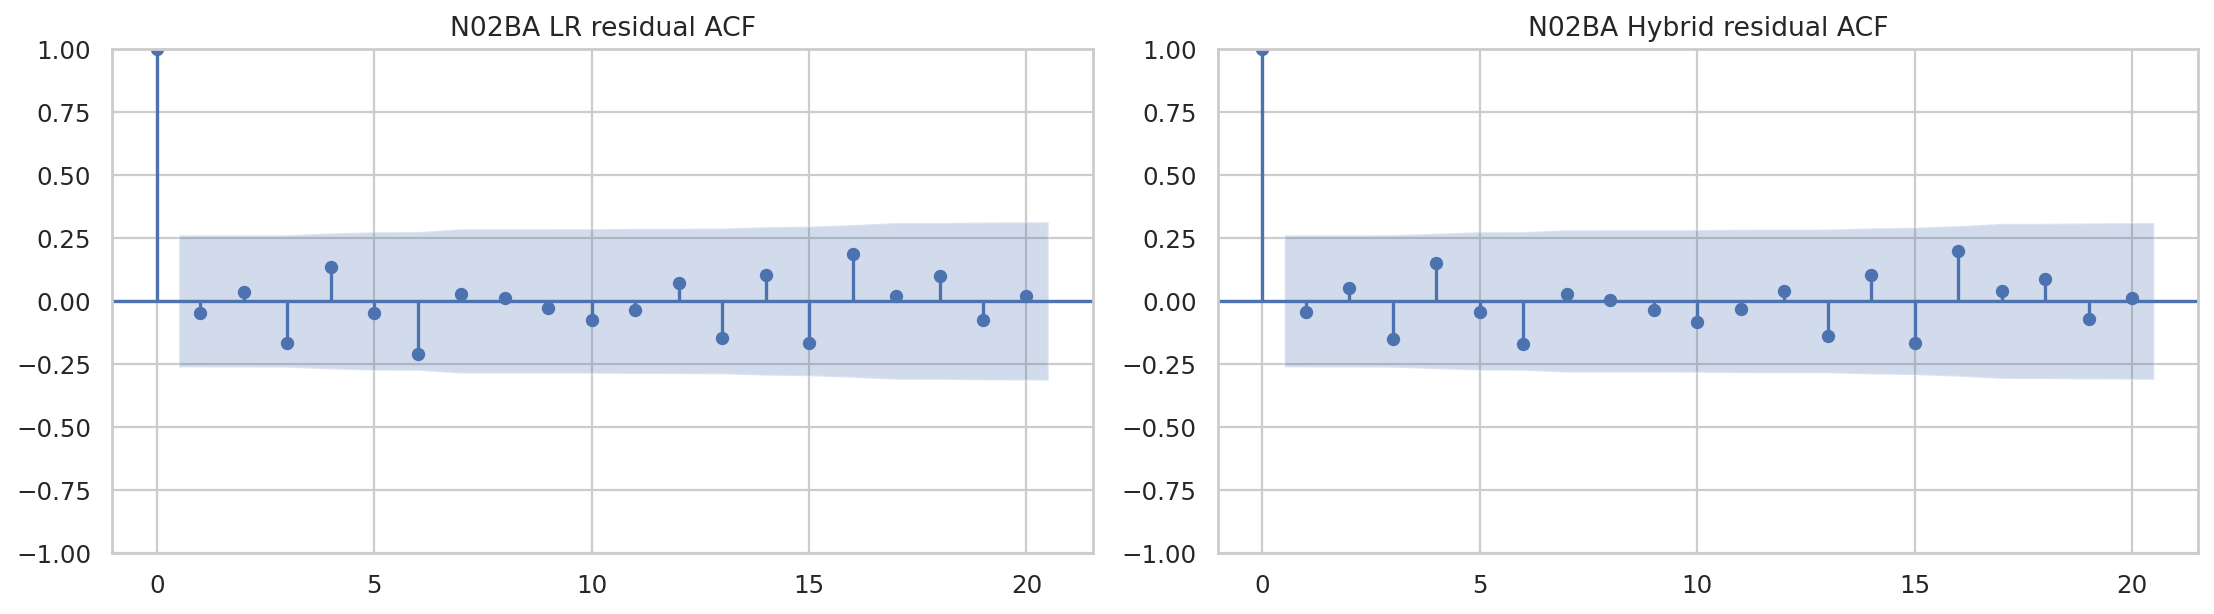

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N02BA_residual_acf_before_after.png


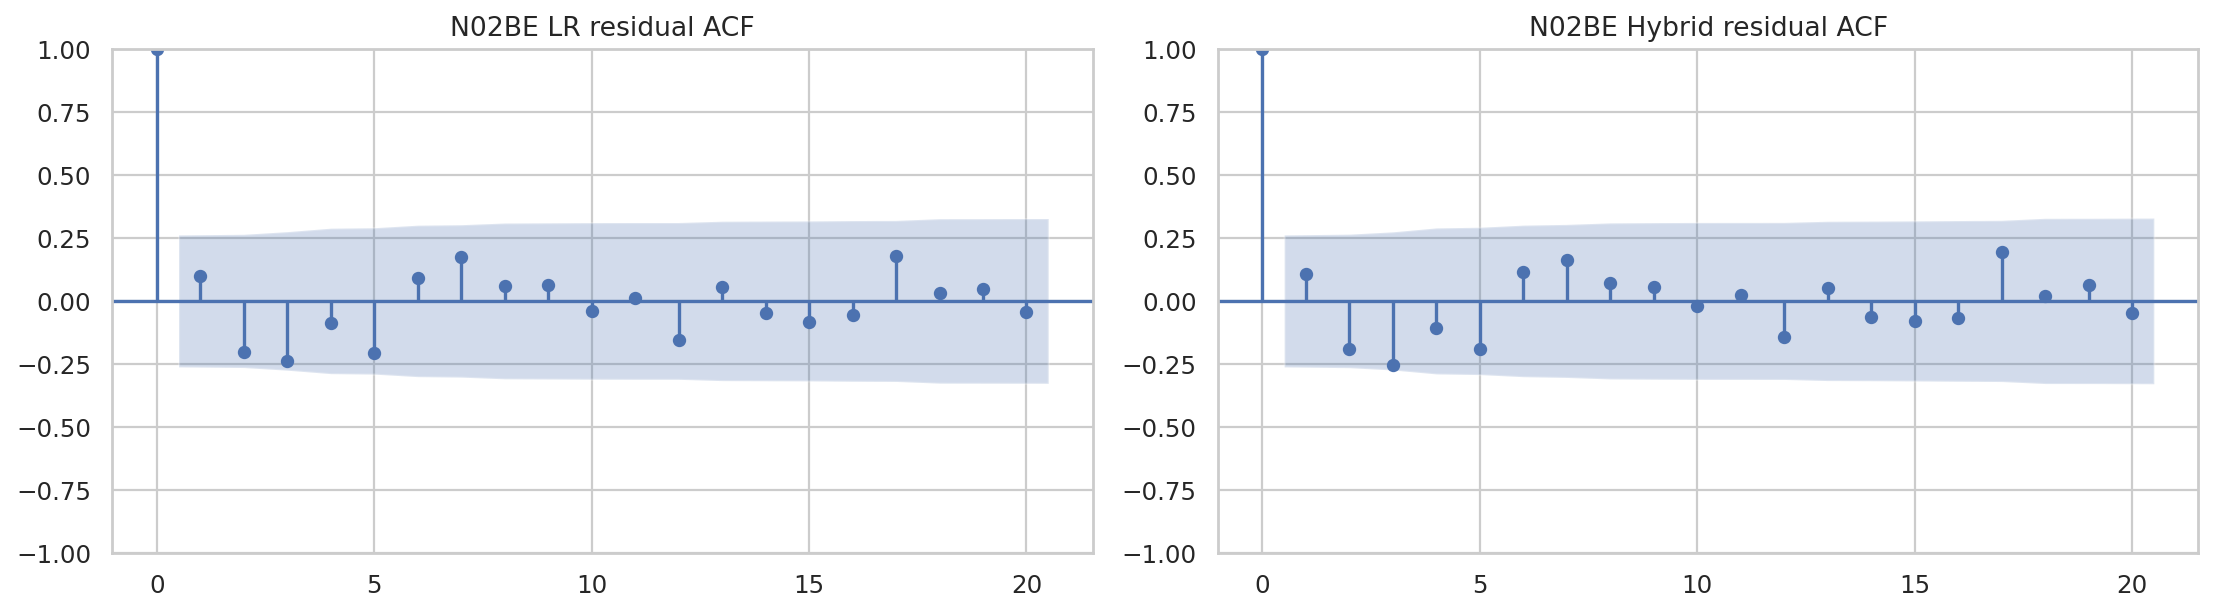

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N02BE_residual_acf_before_after.png


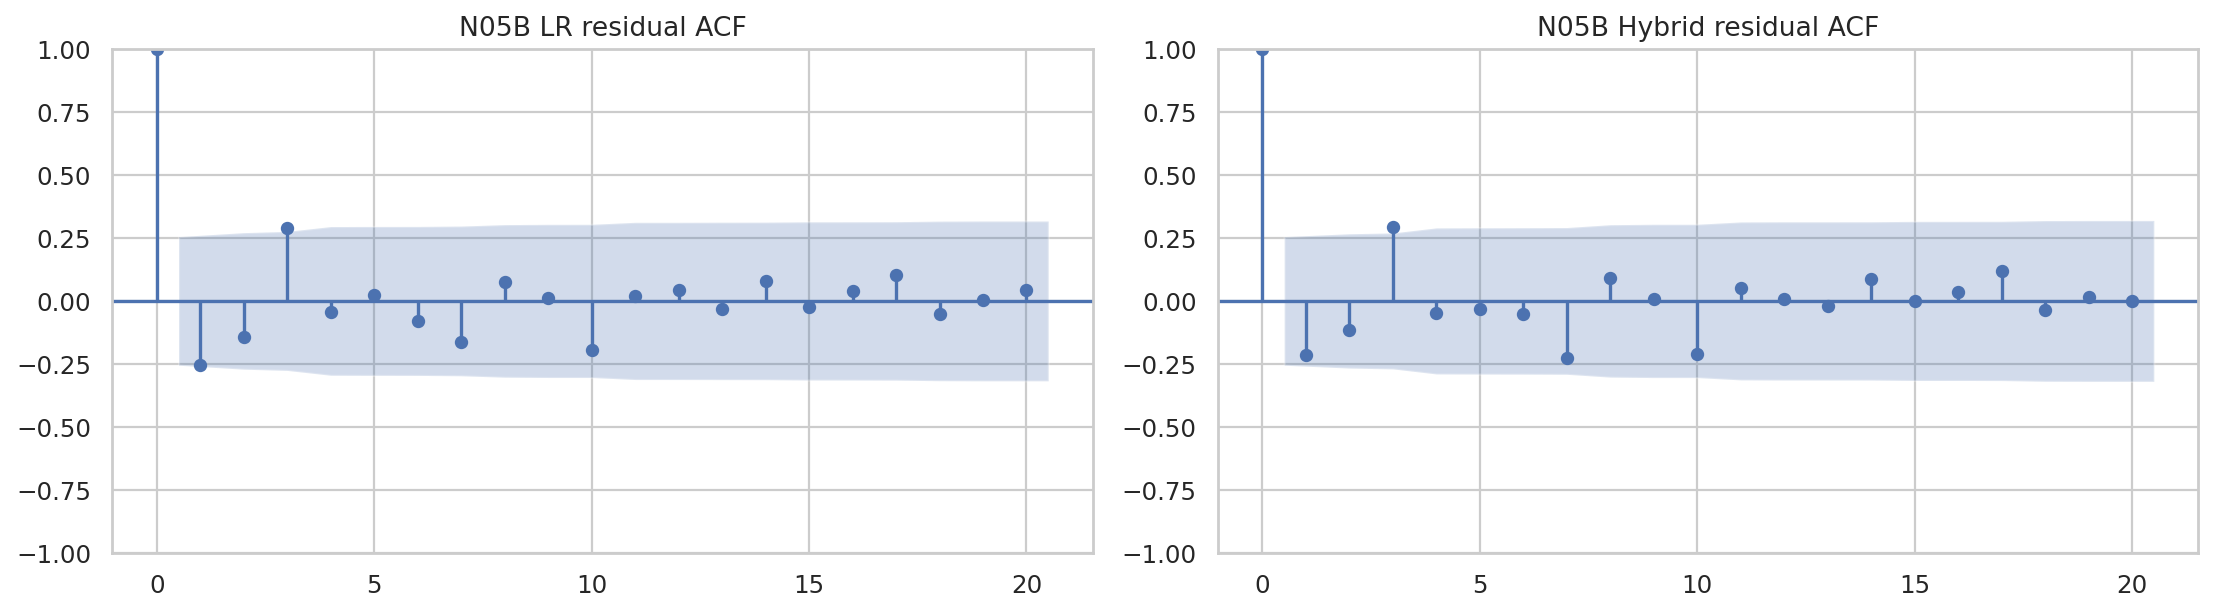

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N05B_residual_acf_before_after.png


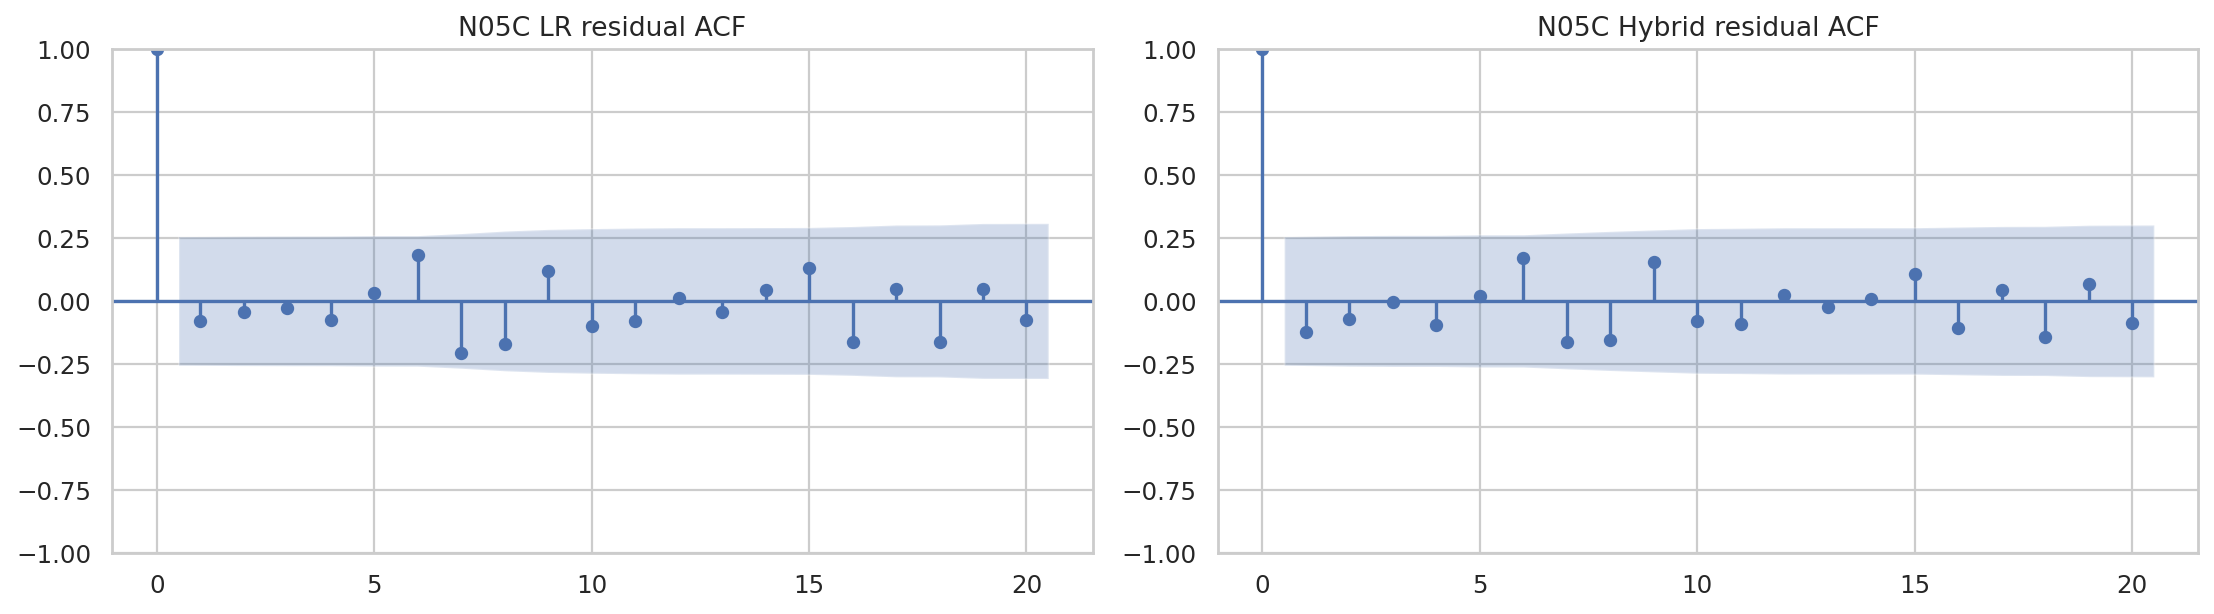

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/N05C_residual_acf_before_after.png


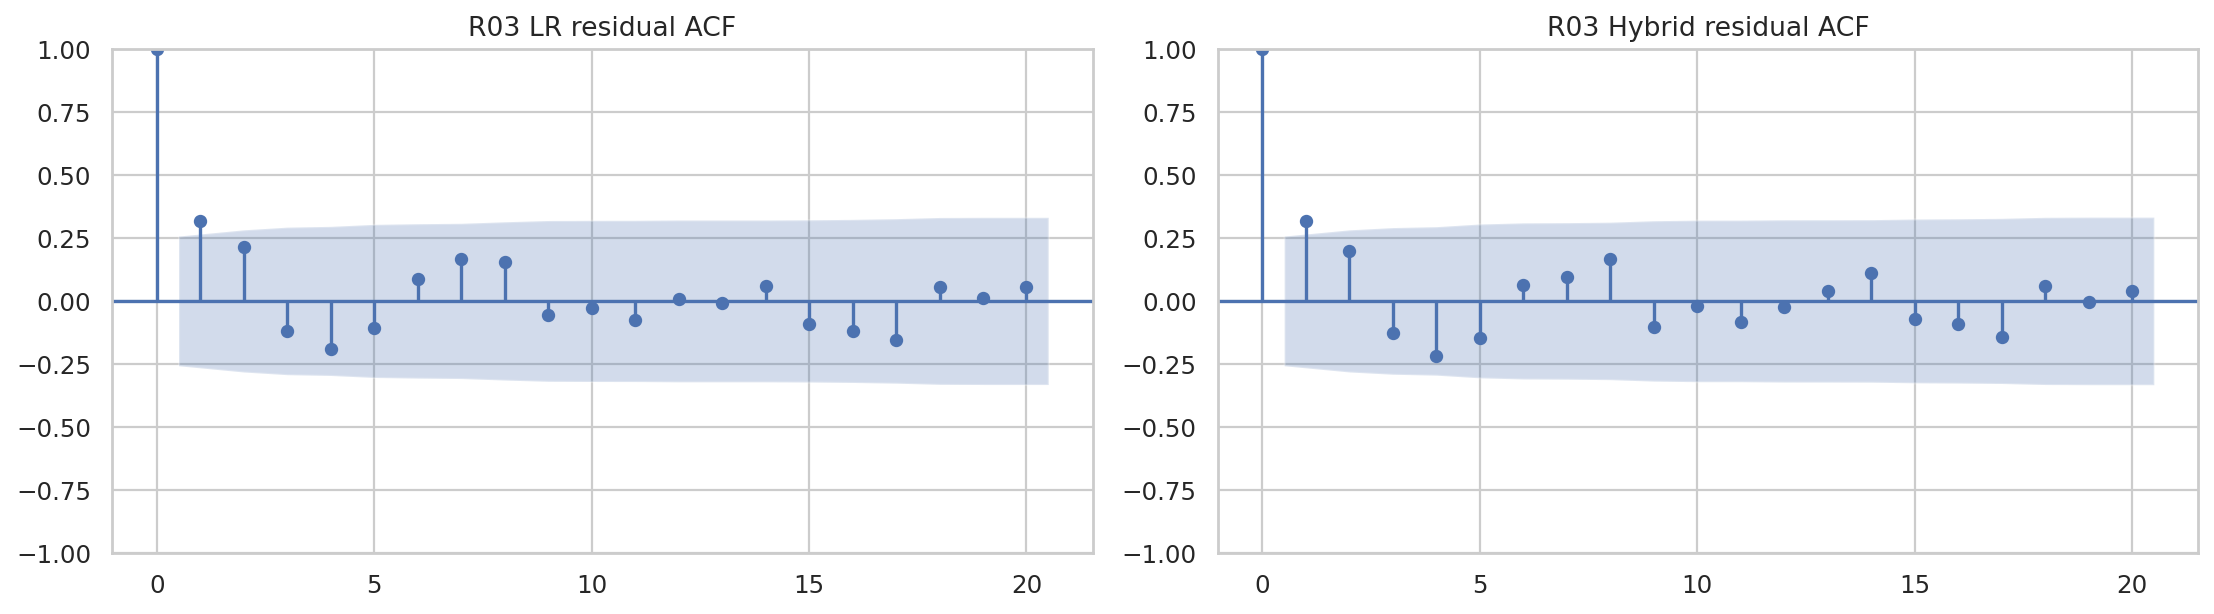

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/R03_residual_acf_before_after.png


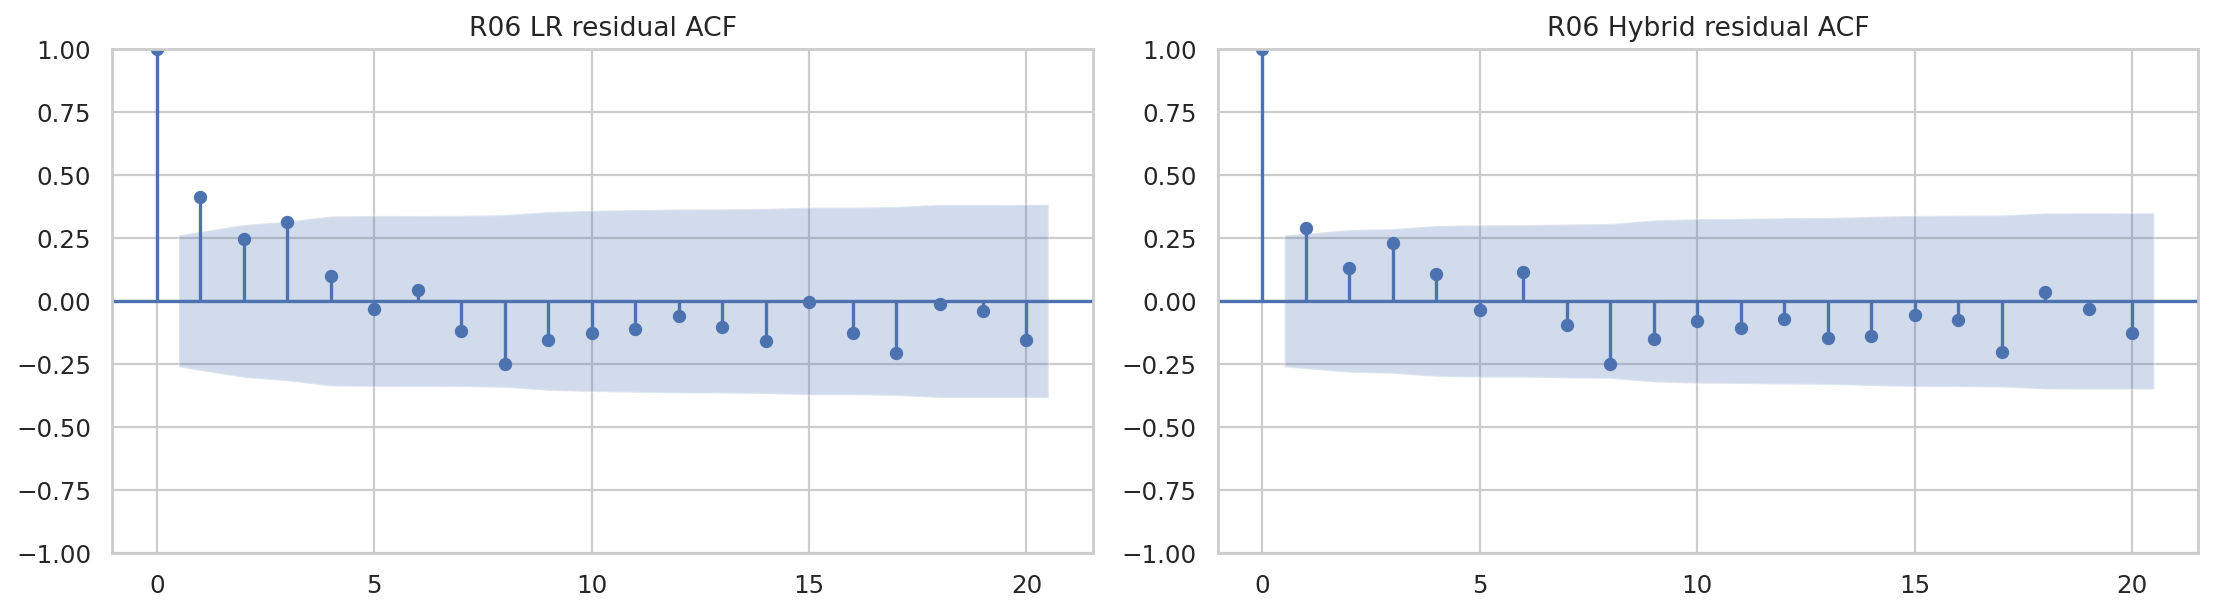

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures/R06_residual_acf_before_after.png


In [15]:
def plot_residual_acf_category(category, nlags=20):
    df = diagnostics_df[diagnostics_df['category'] == category].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=160)
    plot_acf(df['lr_residual'], lags=min(nlags, len(df) - 2), ax=axes[0], title=f'{category} LR residual ACF')
    plot_acf(df['hybrid_residual'], lags=min(nlags, len(df) - 2), ax=axes[1], title=f'{category} Hybrid residual ACF')
    plt.tight_layout()
    out_path = FIG_DIR / f'{category}_residual_acf_before_after.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)

for category in categories:
    plot_residual_acf_category(category)

# Section 6 — Winner and Loser Interpretation

Bagian ini membuat ringkasan metrik untuk membedakan kategori yang terbantu oleh residual correction dan kategori yang tidak terbantu. Label "residual membantu" ditentukan dari perbandingan MSE hybrid terhadap MSE Linear Regression pada test set.

Jika `mse_delta_hybrid_minus_lr` bernilai negatif, artinya residual correction menurunkan error dibanding Linear Regression. Jika nilainya positif, residual correction justru menambah error.

In [16]:
diagnostic_metrics['residual_helped_lr'] = diagnostic_metrics['mse_delta_hybrid_minus_lr'] < 0
diagnostic_metrics['hybrid_vs_lr_improvement_pct'] = (
    (diagnostic_metrics['lr_MSE'] - diagnostic_metrics['hybrid_MSE']) / diagnostic_metrics['lr_MSE'] * 100
).round(2)

diagnostic_metrics[['category', 'experiment', 'optimizer', 'feature_set',
                    'lr_MSE', 'hybrid_MSE', 'mse_delta_hybrid_minus_lr',
                    'hybrid_vs_lr_improvement_pct', 'residual_helped_lr',
                    'baseline_MSE', 'best_residual_MSE_from_csv']].sort_values('category')

,category,experiment,optimizer,feature_set,lr_MSE,hybrid_MSE,mse_delta_hybrid_minus_lr,hybrid_vs_lr_improvement_pct,residual_helped_lr,baseline_MSE,best_residual_MSE_from_csv
0,M01AB,D3_tweedie,PSO,seasonal,65.117402,65.546070,0.428668,-0.66,False,67.020749,65.546070
1,M01AE,D1_log1p,GEO,seasonal,67.353143,66.920215,-0.432928,0.64,True,69.474636,66.920215
2,N02BA,baseline,GEO,base,40.637013,38.870522,-1.766491,4.35,True,38.715477,38.870522
3,N02BE,D1_log1p,PSO,seasonal,2282.426504,2238.458124,-43.968380,1.93,True,2886.454217,2238.458124
4,N05B,baseline,GridSearch,base,160.237967,184.951890,24.713924,-15.42,False,143.225024,184.951890
5,N05C,baseline,Optuna,base,7.766278,7.458585,-0.307693,3.96,True,7.379361,7.458585
6,R03,E1_winsorize,PSO,seasonal,770.053384,699.534144,-70.519240,9.16,True,721.610398,699.534144
7,R06,E1_winsorize,PSO,seasonal,91.570559,73.787598,-17.782961,19.42,True,71.428755,73.787598


# Section 7 — Focus Notes for Main Hypotheses

Bagian ini menghubungkan hasil visualisasi dengan hipotesis utama. Teks ini bisa dipakai sebagai bahan penjelasan di laporan atau paper.

## Hipotesis 1: Residual hanya berguna jika sisa error Linear Regression masih berpola

Bukti yang perlu dilihat ada pada plot residual over time dan residual ACF. Jika residual Linear Regression masih memiliki pola atau autocorrelation, XGBoost punya sesuatu untuk dipelajari. Jika residual hybrid menjadi lebih kecil dan ACF menurun, maka residual correction berhasil.

## Hipotesis 2: Linear Regression sudah cukup kuat setelah fitur lag dan rolling

Bukti yang perlu dilihat ada pada plot actual versus prediction. Jika garis Linear Regression sudah mengikuti data aktual dengan cukup baik, maka residual yang tersisa biasanya kecil atau tidak stabil. Dalam kondisi itu, XGBoost residual bisa sulit memberi tambahan manfaat.

## Hipotesis 7: Outlier membuat residual correction tidak stabil

Bukti yang perlu dilihat ada pada residual over time dan absolute error distribution. Jika ada spike residual yang sangat besar, maka model residual bisa menjadi sensitif. R03 adalah kategori utama untuk hipotesis ini karena pendekatan winsorize sempat menjadi historical winner.

## Hipotesis 8: Robust loss lebih sering membantu target langsung daripada residual

Bukti yang perlu dilihat adalah apakah residual hybrid benar-benar menurunkan error dibanding Linear Regression. Jika robust loss menang pada eksperimen averaging tetapi residual diagnostic tidak membaik, maka masalah utama ada pada target yang noisy, bukan pada residual Linear Regression yang berpola.

## Catatan khusus M01AE

M01AE adalah contoh kategori yang secara historical menang dengan residual. Jika plot menunjukkan residual hybrid lebih dekat ke nol dan absolute error turun, maka kategori ini mendukung bahwa residual correction bermanfaat ketika sisa error masih memiliki pola.

## Catatan khusus R03

R03 adalah kategori yang sensitif terhadap outlier. Jika visual menunjukkan spike residual besar dan perbaikan hanya terjadi pada beberapa titik, maka kesimpulannya adalah residual correction bisa membantu R03, tetapi sangat bergantung pada outlier handling dan kestabilan optimizer.

## Catatan khusus N02BE

N02BE memiliki improvement besar pada pendekatan log transform averaging, bukan residual. Jika residual diagnostic tidak menunjukkan perbaikan kuat, maka masalah utama N02BE lebih terkait skala dan variance target, bukan sisa error Linear Regression.

## Catatan khusus N05B

N05B tetap kuat pada baseline. Jika residual diagnostic menunjukkan hybrid tidak memperbaiki LR, maka ini mendukung dugaan bahwa fitur dasar sudah cukup dan residual tidak membawa pola tambahan yang berguna.

# Section 8 — Save Diagnostic Outputs

Bagian ini menyimpan tabel residual diagnostic dan metric summary ke `OUTPUT_DIR`. Gambar sudah disimpan otomatis di folder `residual_diagnostics_figures`.

In [17]:
diagnostics_df.to_csv(OUTPUT_DIR / 'weekly_residual_diagnostics_detail.csv', index=False)
diagnostic_metrics.to_csv(OUTPUT_DIR / 'weekly_residual_diagnostics_metrics.csv', index=False)
best_residual.to_csv(OUTPUT_DIR / 'weekly_best_residual_methods.csv', index=False)
print('Saved:', OUTPUT_DIR / 'weekly_residual_diagnostics_detail.csv')
print('Saved:', OUTPUT_DIR / 'weekly_residual_diagnostics_metrics.csv')
print('Saved:', OUTPUT_DIR / 'weekly_best_residual_methods.csv')
print('Figures saved in:', FIG_DIR)

Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_residual_diagnostics_detail.csv
Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_residual_diagnostics_metrics.csv
Saved: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/weekly_best_residual_methods.csv
Figures saved in: /content/drive/MyDrive/pharma_weekly_enhancement_outputs/residual_diagnostics_figures
